# UNITER: UNiversal Image-TExt Representation Learning

# https://arxiv.org/pdf/1909.11740

**Authors:** Yen-Chun Chen, Linjie Li, Licheng Yu, Ahmed El Kholy, Faisal Ahmed,
Zhe Gan, Yu Cheng, Jingjing Liu
**Affiliation:** Microsoft Dynamics 365 AI Research
**Venue:** ECCV 2020 (arXiv v3: July 2020)

---

## Abstract

UNITER is a large-scale pre-trained universal model for joint image-text
representation learning. It is trained on four image-text datasets (COCO,
Visual Genome, Conceptual Captions, and SBU Captions) through four
pre-training tasks: Masked Language Modeling (MLM), Masked Region Modeling
(MRM), Image-Text Matching (ITM), and Word-Region Alignment (WRA). Two key
innovations distinguish UNITER from prior work: conditional masking on
pre-training tasks, and an Optimal Transport (OT)-based WRA objective for
fine-grained cross-modal alignment. UNITER achieves state-of-the-art
performance across six V+L tasks spanning nine datasets.

---

## Problems

1. **Task-specific architectures** — Prior vision-language models (MCB, BAN, SCAN,
   MAttNet) are designed for individual tasks, producing highly task-specific
   representations that do not generalize across diverse V+L tasks.

2. **Absence of a universal pre-trained V+L backbone** — Unlike BERT for NLP and
   ImageNet-pretrained CNNs for vision, no generic pre-trained representation
   existed that could serve all V+L tasks simultaneously.

3. **Joint random masking causes cross-modal misalignment** — Prior multimodal
   pre-training methods (ViLBERT, LXMERT) apply random masking to both modalities
   simultaneously, creating scenarios where a masked region and its corresponding
   masked word must be predicted without any cross-modal grounding, leading to
   misaligned representations.

4. **Lack of explicit fine-grained word-region alignment** — Prior models enforce
   cross-modal alignment only implicitly through task-specific losses, without
   explicitly optimizing for local, token-level correspondences between words and
   image regions.

5. **Two-stream architectures impose restricted attention patterns** — Models such as
   ViLBERT and LXMERT restrict cross-modal attention to designated layers,
   increasing parameter count (183M–221M) and limiting the depth of visual-linguistic
   interaction.

---

## Proposed Solutions

1. **Conditional Masking** — During MLM, only words are masked while all image
   regions remain visible; during MRM, only regions are masked while all words
   remain visible. This ensures that masked predictions are always grounded in the
   complete signal from the other modality.

2. **Word-Region Alignment (WRA) via Optimal Transport** — An explicit pre-training
   task that learns fine-grained token-level alignment between words and image regions
   by minimizing the Optimal Transport (OT) distance between their contextualized
   embedding distributions.

3. **Three MRM variants** — To handle the continuous, high-dimensional nature of
   visual features:
   - Masked Region Feature Regression (MRFR): L2 regression to original RoI features
   - Masked Region Classification (MRC): cross-entropy with hard one-hot labels
   - MRC with KL-divergence (MRC-kl): KL divergence with soft detector output
     distribution as supervision

4. **Single-stream unified Transformer** — A single Transformer processes both visual
   and linguistic tokens jointly with unrestricted self-attention, enabling early
   and deep cross-modal interaction with far fewer parameters (86M base, 303M large).

5. **Large-scale multi-dataset pre-training** — Joint training on in-domain (COCO +
   Visual Genome) and out-of-domain (Conceptual Captions + SBU Captions) data
   totaling over 9.5M image-text pairs.

---

## Purpose

To develop a single, universal pre-trained model that:

1. Learns joint contextualized representations for both image regions and text
   tokens, transferable to any V+L downstream task.
2. Addresses the cross-modal misalignment problem in prior masking strategies
   through conditional masking.
3. Explicitly encourages fine-grained word-to-region alignment through an
   OT-based pre-training objective.
4. Outperforms all task-specific and prior pre-trained models across the full
   spectrum of V+L benchmarks.

---

## Methodology

### 3.1 Model Architecture

UNITER consists of three components:

- **Image Embedder**: Extracts pooled RoI features via Faster R-CNN pre-trained
  on Visual Genome. Each region is characterized by a 7-dimensional location
  vector $[x_1, y_1, x_2, y_2, w, h, w \cdot h]$. Both visual and location
  features are projected via FC layers and summed, followed by Layer Normalization.

- **Text Embedder**: WordPiece tokenization following BERT. Each token embedding
  is the sum of word embedding and position embedding, followed by Layer
  Normalization. A modality embedding distinguishes visual from textual tokens.

- **Transformer**: A multi-layer Transformer with unrestricted bidirectional
  self-attention over the concatenated sequence of visual regions and text tokens.

---

### 3.2 Pre-Training Tasks

**Task 1 — Masked Language Modeling (MLM)**

Words $w_m$ are masked with probability 15%. The model predicts the masked
words conditioned on all image regions $v$ (full, unmasked) and unmasked words
$w_{\backslash m}$:

$$\mathcal{L}_{\text{MLM}}(\theta) = -\mathbb{E}_{(w,v) \sim \mathcal{D}}
\log P_\theta(w_m \mid w_{\backslash m},\ v)$$

**Task 2 — Image-Text Matching (ITM)**

Binary prediction of whether an image-sentence pair is matched. The
$[\text{CLS}]$ token representation $s_\theta(w, v)$ is passed through an FC
and sigmoid. Negative pairs are created by randomly replacing the image or text:

$$\mathcal{L}_{\text{ITM}}(\theta) = -\mathbb{E}_{(w,v) \sim \mathcal{D}}
\left[y \log s_\theta(w,v) + (1-y) \log(1 - s_\theta(w,v))\right]$$

**Task 3 — Word-Region Alignment (WRA) via Optimal Transport**

Words $w = \{w_i\}_{i=1}^T$ and regions $v = \{v_j\}_{j=1}^K$ are treated as
two discrete distributions:

$$\mu = \sum_{i=1}^{T} a_i \delta_{w_i}, \quad
\nu = \sum_{j=1}^{K} b_j \delta_{v_j}$$

The OT-based WRA loss minimizes the transportation cost between the two
distributions:

$$\mathcal{L}_{\text{WRA}}(\theta) =
\min_{\mathbf{T} \in \Pi(\mathbf{a}, \mathbf{b})}
\sum_{i=1}^{T} \sum_{j=1}^{K} T_{ij} \cdot c(w_i, v_j)$$

where $\Pi(\mathbf{a}, \mathbf{b}) = \{\mathbf{T} \in \mathbb{R}_+^{T \times K}
\mid \mathbf{T}\mathbf{1}_K = \mathbf{a},\ \mathbf{T}^\top \mathbf{1}_T =
\mathbf{b}\}$, and the cosine distance is used as the cost function:

$$c(w_i, v_j) = 1 - \frac{w_i^\top v_j}{\|w_i\|_2 \|v_j\|_2}$$

The exact OT minimization is intractable; the IPOT algorithm is used to
approximate it efficiently via iterative proximal point updates:

$$\mathbf{T}^{(t+1)} = \arg\min_{\mathbf{T} \in \Pi(\mathbf{a},\mathbf{b})}
\left\{\langle \mathbf{T}, \mathbf{C} \rangle +
\beta \cdot \mathcal{B}(\mathbf{T}, \mathbf{T}^{(t)})\right\}$$

where $\mathcal{B}(\mathbf{T}, \mathbf{T}^{(t)}) =
\sum_{i,j} T_{ij} \log \frac{T_{ij}}{T^{(t)}_{ij}} -
\sum_{i,j} T_{ij} + \sum_{i,j} T^{(t)}_{ij}$ is the generalized KL
Bregman divergence.

**Task 4 — Masked Region Modeling (MRM)**

Regions $v_m$ are masked (visual features replaced by zeros) with probability
15%. Three variants share the base objective:

$$\mathcal{L}_{\text{MRM}}(\theta) =
\mathbb{E}_{(w,v) \sim \mathcal{D}} f_\theta(v_m \mid v_{\backslash m}, w)$$

- **MRFR**: $f_\theta = \sum_{i=1}^{M} \|h_\theta(v_m^{(i)}) -
  r(v_m^{(i)})\|_2^2$ (L2 regression to RoI features)
- **MRC**: $f_\theta = \sum_{i=1}^{M} \text{CE}(c(v_m^{(i)}),\
  g_\theta(v_m^{(i)}))$ (cross-entropy with hard one-hot label)
- **MRC-kl**: $f_\theta = \sum_{i=1}^{M}
  D_{\text{KL}}(\tilde{c}(v_m^{(i)}) \| g_\theta(v_m^{(i)}))$
  (KL divergence with soft detector distribution)

---

### 3.3 Pre-Training Datasets

| Dataset | Type | Train Pairs | Train Images |
|---|---|---|---|
| COCO Captions | In-domain | 533K | 106K |
| VG Dense Captions | In-domain | 5.06M | 101K |
| Conceptual Captions | Out-of-domain | 3.0M | 3.0M |
| SBU Captions | Out-of-domain | 990K | 990K |

**Total training pairs (In+Out):** ~9.58M image-text pairs

---

### 3.4 Model Sizes

| Model | Layers | Hidden | Heads | Parameters |
|---|---|---|---|---|
| UNITER-base | 12 | 768 | 12 | 86M |
| UNITER-large | 24 | 1024 | 16 | 303M |

---

## Results

### Ablation Study (UNITER-base, In-domain data, Table 2)

| Setting | Meta-Sum | VQA | NLVR2 |
|---|---|---|---|
| No pre-training | 314.34 | 67.03 | 51.02 |
| MLM (text only) | 346.24 | 69.39 | 50.86 |
| ITM only | 385.29 | 70.04 | 74.08 |
| MLM + ITM | 393.04 | 71.55 | 75.98 |
| MLM + ITM + MRC-kl | 397.09 | 71.63 | 76.28 |
| MLM + ITM + MRC-kl + MRFR | 399.97 | 71.92 | 76.93 |
| MLM + ITM + MRC-kl + MRFR + WRA | 400.93 | 72.47 | 76.91 |
| w/o conditional masking | 396.51 | 71.68 | 76.15 |
| In-domain + Out-of-domain | **405.24** | **72.70** | **77.18** |

Key ablation findings:
- Conditional masking outperforms joint random masking (400.93 vs. 396.51)
- WRA provides the largest single-task gain on VQA (+0.55%) and RefCOCO+
- MRC-kl outperforms MRC (397.09 vs. 393.97), confirming soft labels are superior
- In-domain + Out-of-domain jointly achieves the highest Meta-Sum (405.24)

### Downstream Task Results (Table 3)

| Task | Prior SOTA | UNITER-base | UNITER-large |
|---|---|---|---|
| VQA test-std | 70.90 | 72.91 | 74.02 |
| VCR Q→AR | 55.00 | 58.20 | 62.80 |
| NLVR2 test-P | 53.50 | 77.85 | 79.98 |
| SNLI-VE test | 71.16 | 78.28 | 79.38 |
| IR Flickr R@1 | 48.60 | 72.52 | 75.56 |
| ZS IR Flickr R@1 | 31.86 | 66.16 | 68.74 |
| RefCOCO+ val | 75.38 | 83.66 | 84.25 |

Notable improvements over prior best:
- NLVR2: +24% absolute over task-specific SOTA (MaxEnt: 53.50)
- SNLI-VE: +7% absolute over prior best
- Zero-shot IR Flickr R@1: +15% absolute improvement
- VCR Q→AR: +2.8% over best concurrent model
- UNITER-base (86M parameters) outperforms ViLBERT (221M) and LXMERT (183M)

---

## Conclusions

UNITER establishes a new paradigm for universal vision-language pre-training
through three principal contributions: (1) conditional masking, which prevents
cross-modal misalignment by ensuring each masked prediction is always grounded
in the complete signal from the intact modality; (2) OT-based Word-Region
Alignment, which provides explicit, fine-grained token-level cross-modal
supervision absent from all prior work; and (3) a thorough ablation study
identifying the optimal combination of pre-training tasks
(MLM + ITM + MRC-kl + MRFR + WRA) and datasets (In-domain + Out-of-domain).

The results demonstrate that a single-stream unified Transformer with
well-designed pre-training objectives can surpass two-stream architectures
(ViLBERT, LXMERT) that use nearly three times the parameters, challenging
the prevailing belief that two-stream designs are inherently superior. UNITER
achieves new state of the art across all six evaluated V+L tasks with
consistent and often large margins, validating both the generalizability of the
learned representations and the importance of the proposed pre-training
innovations.

# UNITER: Mathematical and Statistical Content Summary

---

## 1. Input Representation

### 1.1 Image Region Location Vector

Each detected image region (RoI) is characterized by a 7-dimensional
normalized bounding-box vector:

$$g = \left[\frac{x_1}{W},\ \frac{y_1}{H},\ \frac{x_2}{W},\ \frac{y_2}{H},\
\frac{w}{W},\ \frac{h}{H},\ \frac{w \cdot h}{W \cdot H}\right] \in \mathbb{R}^7$$

where $(x_1, y_1)$ and $(x_2, y_2)$ are the top-left and bottom-right
coordinates, $w$ and $h$ are the region width and height, and $W$, $H$ are
the full image width and height.

**Role:** Encodes both the position and the relative area of each detected
region, providing the model with spatial context that is absent from
appearance features alone. The area term $w \cdot h / (W \cdot H)$ gives
the model a sense of region scale, which is important for spatial reasoning
tasks such as referring expression comprehension.

---

### 1.2 Final Visual Embedding

The visual embedding for each region is obtained by projecting both the
appearance feature $f_{\text{app}}$ (from Faster R-CNN) and the location
feature $g$ through separate fully-connected layers, summing them, and
applying Layer Normalization:

$$v_i = \text{LN}\!\left(\text{FC}(f_{\text{app},i}) +
\text{FC}(g_i)\right)$$

**Role:** Projects heterogeneous visual inputs (continuous appearance features
and geometric coordinates) into a common $d$-dimensional embedding space
shared with text tokens.

---

### 1.3 Text Token Embedding

Each subword token is embedded as the sum of its word embedding and
positional embedding, followed by Layer Normalization:

$$e_i = \text{LN}\!\left(\text{WordEmb}(w_i) + \text{PosEmb}(i)\right)$$

A modality embedding is also added (omitted for brevity) to distinguish
visual from textual tokens.

**Role:** Standard BERT-style text embedding; prepares text tokens for joint
processing with visual tokens in the shared Transformer.

---

## 2. Transformer Self-Attention

UNITER uses a standard multi-layer bidirectional Transformer. At each layer,
scaled dot-product multi-head self-attention is applied over the concatenated
sequence of text tokens and image regions:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(
\frac{QK^\top}{\sqrt{d_k}}\right) V$$

$$\text{MultiHead}(Q, K, V) =
\text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

$$\text{head}_i = \text{Attention}(QW_i^Q,\ KW_i^K,\ VW_i^V)$$

where $d_k = d_{\text{model}} / h$ is the per-head dimension and
$\sqrt{d_k}$ is the scaling factor preventing dot products from becoming
too large.

**Role:** The single unified attention mechanism enables every word token
to attend to every image region and vice versa at every layer,
implementing unrestricted cross-modal interaction — a key architectural
distinction from two-stream models.

---

## 3. Pre-Training Loss Functions

### 3.1 Masked Language Modeling (MLM)

Words are randomly masked with probability $p = 0.15$. The model predicts
masked words $w_m$ conditioned on unmasked words $w_{\backslash m}$ and
all (unmasked) image regions $v$:

$$\mathcal{L}_{\text{MLM}}(\theta) = -\mathbb{E}_{(w,v) \sim \mathcal{D}}
\log P_\theta(w_m \mid w_{\backslash m},\ v)$$

In practice, this is Softmax cross-entropy over the vocabulary at each
masked position. The 15% masking is decomposed as: 80% replaced with
$[\text{MASK}]$, 10% replaced with a random token, 10% left unchanged
(following BERT).

**Role:** Forces the model to predict missing language tokens using both
linguistic context and visual grounding. The conditioning on full image
regions (conditional masking) ensures the prediction is always anchored
in visual evidence.

---

### 3.2 Image-Text Matching (ITM)

Given an image-text pair, the model predicts a binary match label
$y \in \{0, 1\}$ from the $[\text{CLS}]$ token representation via a
sigmoid classifier with output $s_\theta(w, v) \in (0,1)$:

$$\mathcal{L}_{\text{ITM}}(\theta) = -\mathbb{E}_{(w,v) \sim \mathcal{D}}
\left[y \log s_\theta(w,v) + (1-y)\log(1 - s_\theta(w,v))\right]$$

Negative pairs are constructed by randomly replacing either the image or
text with an unrelated sample from the dataset.

**Role:** Trains the model to assess global image-text consistency.
The $[\text{CLS}]$ token aggregates the full joint representation,
making this objective directly aligned with downstream classification
tasks that also use the $[\text{CLS}]$ output.

---

### 3.3 Word-Region Alignment (WRA) via Optimal Transport

This is the most mathematically novel component of UNITER.

#### 3.3.1 Distribution Formulation

Words $\{w_i\}_{i=1}^T$ and image regions $\{v_j\}_{j=1}^K$ are treated
as two discrete probability distributions:

$$\mu = \sum_{i=1}^{T} a_i \delta_{w_i}, \quad
\nu = \sum_{j=1}^{K} b_j \delta_{v_j}$$

where $\delta_{w_i}$ is the Dirac delta centered on word $w_i$, and
the weight vectors $\mathbf{a} \in \Delta^T$, $\mathbf{b} \in \Delta^K$
belong to the probability simplex:

$$\sum_{i=1}^{T} a_i = 1, \quad \sum_{j=1}^{K} b_j = 1,
\quad a_i, b_j \geq 0$$

In practice, uniform weights are used: $a_i = 1/T$, $b_j = 1/K$.

**Role:** Models the word and region embeddings as probability distributions
so that the Optimal Transport framework can be applied to measure their
alignment cost.

---

#### 3.3.2 Optimal Transport Distance and WRA Loss

The WRA loss is the Optimal Transport (OT) distance between $\mu$ and $\nu$,
defined as the minimum cost of transporting one distribution to the other:

$$\mathcal{L}_{\text{WRA}}(\theta) =
\min_{\mathbf{T} \in \Pi(\mathbf{a}, \mathbf{b})}
\sum_{i=1}^{T} \sum_{j=1}^{K} T_{ij} \cdot c(w_i, v_j)$$

where the feasible set of transport plans is:

$$\Pi(\mathbf{a}, \mathbf{b}) = \left\{
\mathbf{T} \in \mathbb{R}_+^{T \times K}\ \Big|\
\mathbf{T}\mathbf{1}_K = \mathbf{a},\
\mathbf{T}^\top \mathbf{1}_T = \mathbf{b}
\right\}$$

Each entry $T_{ij} \geq 0$ represents the fraction of mass transported
from word $w_i$ to region $v_j$, subject to the marginal constraints
ensuring the entire word distribution is transported to the region
distribution.

The cost function is the cosine distance between contextualized embeddings:

$$c(w_i, v_j) = 1 - \frac{w_i^\top v_j}{\|w_i\|_2 \|v_j\|_2}
\in [0, 2]$$

**Role:** Unlike attention-based alignment which is symmetric and
unconstrained, OT enforces a principled allocation constraint:
every word must be fully assigned to regions and every region must
receive mass from words. The resulting transport plan $\mathbf{T}$
is interpretable as a soft alignment matrix between all word-region
pairs. By minimizing $\mathcal{L}_{\text{WRA}}$, the model is explicitly
trained to bring semantically corresponding words and regions close
together in the embedding space.

---

#### 3.3.3 General OT Definition (Wasserstein Distance)

The general continuous OT distance between two measures $\mu$ and $\nu$
is:

$$D_c(\mu, \nu) = \inf_{\gamma \in \Pi(\mu, \nu)}
\mathbb{E}_{(x,y) \sim \gamma}\left[c(x,y)\right]$$

When $c(x,y) = \|x - y\|^2$, this reduces to the squared 2-Wasserstein
distance $W_2^2(\mu, \nu)$, a standard metric in optimal transport theory.

---

#### 3.3.4 IPOT Algorithm for Tractable OT Computation

Exact OT minimization is computationally intractable in general. UNITER
uses the Inexact Proximal point method for Optimal Transport (IPOT),
which iteratively solves:

$$\mathbf{T}^{(t+1)} = \arg\min_{\mathbf{T} \in \Pi(\mathbf{a},\mathbf{b})}
\left\{\langle \mathbf{T}, \mathbf{C} \rangle +
\beta \cdot \mathcal{B}(\mathbf{T}, \mathbf{T}^{(t)})\right\}$$

where:
- $\mathbf{C}_{ij} = c(w_i, v_j)$ is the cost matrix
- $1/\beta$ is the generalized step size
- $\mathcal{B}(\mathbf{T}, \mathbf{T}^{(t)})$ is the generalized KL
  Bregman divergence used as a proximity regularizer:

$$\mathcal{B}(\mathbf{T}, \mathbf{T}^{(t)}) =
\sum_{i,j} T_{ij} \log \frac{T_{ij}}{T^{(t)}_{ij}} -
\sum_{i,j} T_{ij} + \sum_{i,j} T^{(t)}_{ij}$$

The update is implemented via the following closed-form iterative scheme:

$$\mathbf{Q} = \mathbf{A} \odot \mathbf{T}^{(t)}, \quad
\mathbf{A}_{ij} = e^{-C_{ij}/\beta}$$

$$\delta = \frac{1}{n \mathbf{Q}\sigma}, \quad
\sigma = \frac{1}{m \mathbf{Q}^\top \delta}$$

$$\mathbf{T}^{(t+1)} = \text{diag}(\delta)\,\mathbf{Q}\,\text{diag}(\sigma)$$

where $\odot$ is the Hadamard (element-wise) product.

**Role:** Provides a tractable, numerically stable approximation to the
exact OT solution. The proximal regularization ensures each iterate
remains close to the previous solution, preventing oscillation.
The paper notes that the Sinkhorn algorithm (an alternative OT solver
using entropy regularization) was empirically found to be numerically
unstable for this application, motivating the choice of IPOT.

---

### 3.4 Masked Region Modeling (MRM)

Regions are randomly masked with probability $p = 0.15$.
All three MRM variants share the same base objective structure:

$$\mathcal{L}_{\text{MRM}}(\theta) =
\mathbb{E}_{(w,v) \sim \mathcal{D}}\,
f_\theta(v_m \mid v_{\backslash m},\ w)$$

The three variants differ only in the choice of $f_\theta$:

#### Variant 1: Masked Region Feature Regression (MRFR)

$$f_\theta = \sum_{i=1}^{M}
\left\|h_\theta\!\left(v_m^{(i)}\right) -
r\!\left(v_m^{(i)}\right)\right\|_2^2$$

where $h_\theta(v_m^{(i)})$ is the FC-projected Transformer output and
$r(v_m^{(i)})$ is the original pooled RoI feature.

**Role:** L2 regression loss. Trains the model to reconstruct the raw
visual appearance of masked regions from context, analogous to MLM
but in the continuous feature space.

#### Variant 2: Masked Region Classification (MRC)

$$f_\theta = \sum_{i=1}^{M}
\text{CE}\!\left(c\!\left(v_m^{(i)}\right),\
g_\theta\!\left(v_m^{(i)}\right)\right)$$

where $c(v_m^{(i)}) \in \{0,1\}^K$ is a one-hot label vector (the
highest-confidence Faster R-CNN category) and
$g_\theta(v_m^{(i)}) \in \Delta^K$ is the predicted class distribution.

**Role:** Hard-label cross-entropy for object category prediction.
Treats the noisy detector output as ground truth, which may introduce
label noise for ambiguous regions.

#### Variant 3: MRC with KL-Divergence (MRC-kl)

$$f_\theta = \sum_{i=1}^{M}
D_{\text{KL}}\!\left(\tilde{c}\!\left(v_m^{(i)}\right)\ \Big\|
\ g_\theta\!\left(v_m^{(i)}\right)\right)$$

where $\tilde{c}(v_m^{(i)}) \in \Delta^K$ is the full soft probability
distribution output by Faster R-CNN (rather than a hard one-hot vector),
and the KL divergence is:

$$D_{\text{KL}}(p \| q) = \sum_{k=1}^{K} p_k \log \frac{p_k}{q_k}$$

**Role:** Soft-label knowledge distillation from the detector. By using
the full class probability distribution as supervision, MRC-kl avoids
the hard label assumption and incorporates uncertainty in the detector's
predictions. This is why MRC-kl outperforms MRC in all ablations.

---

## 4. Downstream Fine-Tuning Objectives

### 4.1 Classification Tasks

For VQA, VCR, NLVR2, Visual Entailment, and RE Comprehension, a
cross-entropy loss is minimized over the predicted class distribution:

$$\mathcal{L}_{\text{cls}} = -\sum_{c=1}^{C} y_c \log \hat{p}_c$$

where $y_c$ is the ground-truth label (soft for VQA, one-hot for others)
and $\hat{p}_c$ is the model's predicted probability for class $c$.

For VQA specifically, soft target scores are assigned based on the
proportion of human annotators choosing each answer:

$$y_c = \min\!\left(1,\ \frac{\text{count}(c)}{3}\right)$$

### 4.2 Image-Text Retrieval

Formulated as a ranking problem. A triplet loss maximizes the margin
between a positive pair score and two negative pair scores:

$$\mathcal{L}_{\text{triplet}} =
\max(0,\ \Delta - s_+(w, v) + s_-(w, v'))
+ \max(0,\ \Delta - s_+(w, v) + s_-(w', v))$$

where $s_+(w,v)$ is the similarity of the matched pair, $s_-(w,v')$ and
$s_-(w',v)$ are the similarities of the negative pairs, and $\Delta$ is
the margin hyperparameter.

---

## 5. Combined Pre-Training Objective

Each mini-batch randomly samples exactly one pre-training task, and only
that task's loss is used for the SGD update:

$$\mathcal{L}_{\text{total}} \in
\left\{\mathcal{L}_{\text{MLM}},\
\mathcal{L}_{\text{ITM}},\
\mathcal{L}_{\text{WRA}},\
\mathcal{L}_{\text{MRM}}\right\}$$

This single-task-per-batch strategy avoids loss weighting hyperparameters
and ensures each task receives dedicated gradient updates.

---

## 6. Evaluation Metrics

| Task | Metric | Mathematical Definition |
|---|---|---|
| VQA | VQA-Score | $\min(1,\ \text{agreement count} / 3)$ per answer |
| VCR | Accuracy | $\frac{1}{N}\sum_{i=1}^N \mathbf{1}[\hat{y}_i = y_i]$ |
| NLVR2 | Accuracy + Consistency | Accuracy over binary labels; Consistency over grouped pairs |
| SNLI-VE | 3-class Accuracy | Standard multiclass accuracy |
| Retrieval | Recall@$k$ | $\text{R@}k = \frac{|\{\text{relevant} \cap \text{top-}k\}|}{|\text{relevant}|}$ |
| RE Comprehension | Accuracy | Fraction of queries correctly localized |

**Meta-Sum** is used as a global metric aggregating all benchmarks:

$$\text{Meta-Sum} = \sum_{\text{task}} \sum_{\text{split}} \text{score}_{\text{task,split}}$$

This provides a single scalar summary of overall model quality across all
evaluated downstream tasks simultaneously.

---

## 7. Conditional Masking vs. Joint Random Masking

### Mathematical Motivation

In joint random masking (used in ViLBERT, LXMERT), both modalities are
masked simultaneously. The MLM objective becomes:

$$\mathcal{L}_{\text{MLM}}^{\text{joint}}(\theta) =
-\mathbb{E} \log P_\theta(w_m \mid w_{\backslash m},\ v_{\backslash m})$$

This creates a scenario where $P(w_m \cap v_m^{(j)} \text{ both masked})
= p_w \cdot p_v = 0.15 \times 0.15 = 0.0225$, meaning 2.25% of
word-region pairs share the property of both being masked simultaneously.
When this co-occurrence happens for semantically related pairs, the model
must predict each from a degraded signal, causing misalignment.

UNITER's conditional masking removes this risk:

$$\mathcal{L}_{\text{MLM}}^{\text{cond}}(\theta) =
-\mathbb{E} \log P_\theta(w_m \mid w_{\backslash m},\ v)
\quad \text{(all } v \text{ intact)}$$

$$\mathcal{L}_{\text{MRM}}^{\text{cond}}(\theta) =
\mathbb{E}\, f_\theta(v_m \mid v_{\backslash m},\ w)
\quad \text{(all } w \text{ intact)}$$

**Empirical result:** Conditional masking achieves Meta-Sum 399.97 vs.
396.51 for joint masking (Table 2, rows 10 vs. 12), a gain of +1.46
points, confirming the mathematical argument.

# UNITER: Problem — Limitation — Solution Analysis

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in UNITER |
|---|---|---|---|
| 1 | **Absence of a universal pre-trained V+L backbone** — No single generic pre-trained model existed capable of serving all vision-language tasks, analogous to BERT for NLP or ImageNet CNNs for vision. | Every V+L model (MCB, BAN, SCAN, MAttNet) requires task-specific architecture design and training from scratch on individual datasets, producing representations that cannot transfer across tasks and are prone to overfitting on limited task-specific data. | A single unified Transformer pre-trained on 9.58M image-text pairs across four datasets (COCO, VG, CC, SBU), producing transferable joint embeddings fine-tunable to any V+L task via minimal output head modification. |
| 2 | **Cross-modal misalignment from joint random masking** — Prior methods (ViLBERT, LXMERT) apply random masking to both modalities simultaneously, creating scenarios where a masked region and its semantically corresponding masked word must be predicted without cross-modal grounding. | Joint masking produces a 2.25% probability ($0.15 \times 0.15$) of co-masking semantically paired word-region pairs, forcing blind predictions that propagate misaligned representations into the learned embeddings and degrade downstream performance. | Conditional masking: MLM masks only words while keeping all image regions fully visible; MRM masks only regions while keeping all text tokens fully visible. This guarantees every masked prediction is always grounded in the complete signal from the intact modality. |
| 3 | **No explicit fine-grained word-region alignment objective** — Prior pre-training methods enforce cross-modal alignment only implicitly through task-level losses (e.g., VQA accuracy, caption matching), without directly optimizing token-level correspondences between words and image regions. | Implicit alignment is coarse and inconsistent across layers and heads; the model may learn to associate global image-level features with full sentences without establishing precise local correspondences between individual words and specific visual regions, limiting performance on tasks requiring region-level reasoning. | Word-Region Alignment (WRA) via Optimal Transport: explicitly minimizes the OT distance $\mathcal{L}_{\text{WRA}} = \min_{\mathbf{T} \in \Pi(\mathbf{a},\mathbf{b})} \sum_{i,j} T_{ij} c(w_i, v_j)$ between word and region embedding distributions, yielding a principled, sparse, interpretable token-level alignment plan $\mathbf{T}$. |
| 4 | **Hard one-hot labels introduce noise in masked region supervision** — MRC-style masked region prediction uses the highest-confidence Faster R-CNN category as a hard one-hot label, treating noisy detector outputs as ground truth. | Hard labels discard the uncertainty in the detector's prediction distribution; for ambiguous or partially occluded regions, a single incorrect hard label actively misdirects the model, reducing the quality of visual representations learned during pre-training. | MRC-kl: uses the full soft probability distribution output by Faster R-CNN as a supervision signal via KL divergence $D_{\text{KL}}(\tilde{c}(v_m) \| g_\theta(v_m))$, preserving detection uncertainty and providing richer supervision. Ablations confirm MRC-kl (397.09 Meta-Sum) outperforms MRC (393.97). |
| 5 | **Two-stream architectures impose restricted cross-modal attention** — Models such as ViLBERT and LXMERT process vision and language through separate single-modal Transformers, fusing them only at designated cross-attention layers, with constrained inter-modal attention patterns. | Restricted attention prevents deep, all-layer interaction between visual and linguistic tokens, limiting the richness of cross-modal representations. Two-stream designs also require substantially more parameters (ViLBERT: 221M, LXMERT: 183M), increasing computational cost without commensurate performance gains. | A single-stream unified Transformer that concatenates visual and linguistic tokens into one sequence, enabling unrestricted bidirectional self-attention between every word and every image region at every layer. UNITER-base (86M parameters) outperforms both two-stream models. |
| 6 | **Sub-optimal combination of pre-training tasks** — Prior work applies pre-training tasks without systematic evaluation of their individual and combined contributions, leaving the optimal task combination undetermined. | Without ablation evidence, models may include harmful tasks (e.g., Sentence-Image Relationship Prediction shown by VL-BERT to hurt performance) or omit beneficial complementary tasks, leading to suboptimal pre-trained representations. | Comprehensive ablation study over 14 settings evaluating all combinations of MLM, ITM, MRC, MRC-kl, MRFR, and WRA using Meta-Sum as a global metric, identifying the optimal combination: MLM + ITM + MRC-kl + MRFR + WRA (Meta-Sum: 400.93 in-domain, 405.24 in+out-domain). |
| 7 | **Intractability of exact Optimal Transport computation** — The exact minimization of the OT objective over the transport plan $\mathbf{T}$ is computationally intractable for large sequences, and the alternative Sinkhorn algorithm is numerically sensitive to its regularization hyperparameter $\epsilon$. | Exact OT is NP-hard in general; the Sinkhorn algorithm's entropy regularization introduces a bias-variance tradeoff controlled by $\epsilon$, which is empirically difficult to tune and produces unstable gradients in large-scale Transformer training. | The IPOT algorithm approximates OT via iterative proximal point updates using a generalized KL Bregman divergence regularizer, requiring only matrix-vector products and providing numerical stability without sensitive hyperparameter tuning. |
| 8 | **In-domain data alone limits generalization for unseen images** — Pre-training exclusively on COCO and Visual Genome constrains the visual and linguistic diversity of the learned representations to the distribution of these two datasets. | Models pre-trained only on in-domain data cannot leverage the broader visual and linguistic diversity available in large web-harvested datasets, limiting their generalization to downstream tasks involving images or language styles not well-represented in COCO or VG. | Joint pre-training on both in-domain (COCO+VG: ~5.6M pairs) and out-of-domain (CC+SBU: ~4.0M pairs) data, yielding consistent improvement from 400.93 to 405.24 Meta-Sum and demonstrating that out-of-domain diversity provides complementary, additive learning signal. |
| 9 | **NLVR2 requires two-image reasoning absent from single image-text pre-training** — UNITER is pre-trained on single image-sentence pairs, creating a structural mismatch when fine-tuning on NLVR2, which requires joint reasoning over two images and one caption. | Direct fine-tuning of a single-image pre-trained model on two-image inputs as a naive concatenated triplet degrades performance, as the model has no pre-trained mechanism for cross-image interaction, yielding suboptimal representations for paired-image reasoning. | Three architectural variants are evaluated: Triplet (concatenated images), Pair (independent encoding with concatenated CLS tokens), and Pair-biattn (bidirectional cross-image attention on top of Pair). Pair-biattn achieves the best performance (77.18 dev), demonstrating that minimal architectural surgery suffices to adapt a single-image pre-trained model to multi-image tasks. |

In [1]:
# ============================================================
# UNITER: UNiversal Image-TExt Representation Learning
# Educational PyTorch Implementation on CIFAR-10 Subset
# ============================================================
# CORE PAPER IDEAS REPLICATED:
# 1. Single-stream unified Transformer processing BOTH visual
#    tokens (image patches as RoI surrogates) and linguistic
#    tokens (synthetic captions) in ONE shared sequence
# 2. Four-component visual embedding:
#    appearance + location + modality + position
# 3. CONDITIONAL MASKING:
#    - MLM masks only words (image always fully visible)
#    - MRM masks only regions (text always fully visible)
# 4. Three MRM variants: MRFR (L2), MRC (CE), MRC-kl (KL)
# 5. Image-Text Matching (ITM) for global alignment
# 6. Word-Region Alignment (WRA) via cosine-distance transport
#    approximation (simplified OT surrogate)
# 7. All tasks jointly pre-train a universal representation
# ============================================================

# ---- Standard Library ----
import math
import random
import warnings
import numpy as np
from collections import defaultdict

warnings.filterwarnings("ignore")

# ---- PyTorch ----
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

# ---- Torchvision ----
from torchvision import datasets, transforms

# ---- Visualization ----
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# ============================================================
# SECTION 0 — REPRODUCIBILITY & CONFIGURATION
# ============================================================

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Training Settings ----
NUM_EPOCHS   = 5
BATCH_SIZE   = 32
LR           = 2e-5
WEIGHT_DECAY = 1e-4
WARMUP_RATIO = 0.10
SUBSET_TRAIN = 2000
SUBSET_TEST  = 400
NUM_CLASSES  = 10

# ---- CIFAR-10 ----
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird",  "cat",  "deer",
    "dog",      "frog",       "horse", "ship", "truck"
]

# ---- Model Architecture ----
D_MODEL     = 128      # hidden dimension
N_HEADS     = 4        # attention heads
N_LAYERS    = 4        # Transformer layers
FF_DIM      = D_MODEL * 4
DROPOUT     = 0.1

# ---- Visual Tokens (RoI surrogates) ----
PATCH_SIZE  = 8
N_PATCHES   = (32 // PATCH_SIZE) ** 2    # 16 patches

# ---- Language Tokens ----
MAX_TEXT_LEN = 12

# ---- Segment / Modality IDs ----
SEG_TEXT    = 0    # text modality
SEG_IMAGE   = 1    # image modality

# ---- Matplotlib Style ----
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "figure.dpi"       : 130,
})
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

print(f"Device  : {DEVICE}")
print(f"D_MODEL : {D_MODEL} | N_HEADS : {N_HEADS} | "
      f"N_LAYERS : {N_LAYERS} | N_PATCHES : {N_PATCHES}")

Device  : cuda
D_MODEL : 128 | N_HEADS : 4 | N_LAYERS : 4 | N_PATCHES : 16


In [3]:
# ============================================================
# SECTION 1 — VOCABULARY & SYNTHETIC CAPTION GENERATOR
# ============================================================
# UNITER is pre-trained on real image-caption pairs (COCO, VG,
# CC, SBU). Since CIFAR-10 has no captions, we generate simple
# synthetic captions per class to simulate the (image, text)
# paired input structure required by UNITER's architecture.
# ============================================================

CAPTION_TEMPLATES = [
    "a photo of a {}",
    "an image showing a {}",
    "this picture contains a {}",
    "a clear view of a {}",
    "a snapshot of a {}",
]

SPECIAL_TOKENS = ["[PAD]", "[CLS]", "[SEP]",
                  "[MASK]", "[UNK]"]

def build_vocab():
    """Build word-level vocabulary from caption templates."""
    words = set(SPECIAL_TOKENS)
    for cls in CIFAR10_CLASSES:
        for tmpl in CAPTION_TEMPLATES:
            words.update(tmpl.format(cls).split())
    return {w: i for i, w in enumerate(sorted(words))}

VOCAB      = build_vocab()
VOCAB_SIZE = len(VOCAB)
PAD_ID     = VOCAB["[PAD]"]
CLS_ID     = VOCAB["[CLS]"]
SEP_ID     = VOCAB["[SEP]"]
MASK_ID    = VOCAB["[MASK]"]

def caption_to_tokens(class_idx, max_len=MAX_TEXT_LEN):
    """
    Converts a CIFAR-10 class index to a padded token-ID tensor.
    Format: [CLS] word1 word2 ... wordN [SEP] [PAD] ...
    This mirrors UNITER's WordPiece tokenized text input.
    """
    tmpl    = random.choice(CAPTION_TEMPLATES)
    caption = tmpl.format(CIFAR10_CLASSES[class_idx])
    words   = ["[CLS]"] + caption.split() + ["[SEP]"]
    ids     = [VOCAB.get(w, VOCAB["[UNK]"]) for w in words]
    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))
    else:
        ids = ids[:max_len - 1] + [SEP_ID]
    return torch.tensor(ids, dtype=torch.long)

def apply_conditional_mlm(token_ids, mask_prob=0.15):
    """
    CONDITIONAL MASKING for MLM (Task 1 from UNITER).
    Only TEXT tokens are masked; image regions remain fully visible.

    Key difference from prior work (ViLBERT, LXMERT):
    UNITER never masks both modalities simultaneously, preventing
    the misalignment problem where a masked word AND its
    corresponding masked region must both be predicted blindly.

    Returns:
        masked_ids : token IDs with ~15% replaced by [MASK]
        mlm_labels : -100 for unmasked (ignored by CrossEntropy),
                     true token ID for masked positions
    """
    labels = token_ids.clone()
    mask   = torch.rand(token_ids.shape) < mask_prob
    # Never mask structural special tokens
    special = ((token_ids == CLS_ID) | (token_ids == SEP_ID) |
               (token_ids == PAD_ID))
    mask[special]       = False
    masked_ids          = token_ids.clone()
    masked_ids[mask]    = MASK_ID
    labels[~mask]       = -100    # ignore_index for CrossEntropy
    return masked_ids, labels

def apply_conditional_mrm(n_patches, mask_prob=0.15):
    """
    CONDITIONAL MASKING for MRM (Task 4 from UNITER).
    Only IMAGE REGIONS are masked; text remains fully visible.

    In the paper, masking is done by replacing the visual feature
    vector with zeros (not token replacement). We return a boolean
    mask indicating which patches to zero out.
    """
    mask = torch.rand(n_patches) < mask_prob
    return mask    # True = this patch should be zeroed out

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Sample tokens   : {caption_to_tokens(0)}")

Vocabulary size : 27
Sample tokens   : tensor([ 0,  5, 19, 18,  5,  6,  3,  2,  2,  2,  2,  2])


In [4]:
# ============================================================
# SECTION 2 — DATASET PREPARATION
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

train_full = datasets.CIFAR10("./data", train=True,
                               download=True, transform=transform)
test_full  = datasets.CIFAR10("./data", train=False,
                               download=True, transform=transform)

train_loader = DataLoader(
    Subset(train_full, range(SUBSET_TRAIN)),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(
    Subset(test_full,  range(SUBSET_TEST)),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train : {SUBSET_TRAIN} | Test : {SUBSET_TEST}")

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


Train : 2000 | Test : 400


In [5]:
# ============================================================
# SECTION 3 — MODEL BUILDING BLOCKS
# ============================================================

# ------------------------------------------------------------
# 3.1 Image Embedder
# ------------------------------------------------------------
# UNITER's Image Embedder:
#   v_i = LN(FC(appearance_i) + FC(location_i))
# plus a modality embedding to identify visual tokens.
#
# We simulate:
#   - Appearance feature: Faster R-CNN RoI pool → here: patch projection
#   - Location feature: 7-d normalized bbox → here: learned patch position
#   - Modality embedding: distinguishes image tokens from text tokens
# ------------------------------------------------------------

class ImageEmbedder(nn.Module):
    """
    Encodes image patches as visual token embeddings.
    Replicates UNITER's Image Embedder:
        v_i = LN(FC(f_app_i) + FC(g_i) + modality_emb)
    where f_app is the appearance feature (Faster R-CNN RoI pool)
    and g is the 7-d location feature.
    """
    def __init__(self, img_size=32, patch_size=PATCH_SIZE,
                 in_ch=3, d_model=D_MODEL):
        super().__init__()
        self.ps       = patch_size
        n_patches     = (img_size // patch_size) ** 2
        patch_dim     = in_ch * patch_size * patch_size

        # Appearance feature projection: FC(f_app)
        # Simulates Fast R-CNN pooled RoI feature projection
        self.appearance_proj = nn.Linear(patch_dim, d_model)

        # Location feature: learned geometry embedding per patch position
        # Simulates UNITER's FC(g) where g = [x1,y1,x2,y2,w,h,wh]
        self.location_emb = nn.Embedding(n_patches, d_model)

        # Modality embedding: identifies tokens as IMAGE (index=1)
        # Equivalent to UNITER's 'modality embedding' summed at LN
        self.modality_emb = nn.Embedding(2, d_model)

        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, x, region_mask=None):
        """
        x           : (B, C, H, W)
        region_mask : (B, N_PATCHES) bool — True = mask this patch
                      (conditional MRM: zero out masked patches)
        Returns     : (B, N_PATCHES, D_MODEL)
        """
        B, C, H, W = x.shape
        ps = self.ps

        # Extract non-overlapping patches: (B, N_PATCHES, patch_dim)
        p = x.unfold(2, ps, ps).unfold(3, ps, ps)
        p = p.contiguous().view(B, C, -1, ps, ps)
        p = p.permute(0, 2, 1, 3, 4).contiguous()
        p = p.view(B, -1, C * ps * ps)

        n = p.size(1)

        # CONDITIONAL MRM: replace masked region features with zeros
        # Paper: "visual features of the masked region are replaced by zeros"
        if region_mask is not None:
            # region_mask: (B, N) or (N,) bool
            if region_mask.dim() == 1:
                region_mask = region_mask.unsqueeze(0).expand(B, -1)
            p[region_mask] = 0.0

        # Appearance: FC(f_app)
        app = self.appearance_proj(p)                    # (B, N, D)

        # Location: learned geometry embedding
        patch_idx = torch.arange(n, device=x.device)
        loc       = self.location_emb(patch_idx)\
                        .unsqueeze(0)                    # (1, N, D)

        # Modality embedding for image tokens (index=1)
        mod_ids = torch.ones(B, n, dtype=torch.long,
                             device=x.device)
        mod     = self.modality_emb(mod_ids)             # (B, N, D)

        # v_i = LN(FC(app) + FC(loc) + modality)
        v = self.norm(app + loc + mod)
        return self.drop(v)

In [6]:
# ------------------------------------------------------------
# 3.2 Text Embedder
# ------------------------------------------------------------
# UNITER's Text Embedder:
#   e_i = LN(WordEmb(w_i) + PosEmb(i) + ModalityEmb(0))
# Modality embedding index=0 identifies TEXT tokens.
# ------------------------------------------------------------

class TextEmbedder(nn.Module):
    """
    Encodes text tokens into contextualized embeddings.
    Replicates UNITER's Text Embedder:
        e_i = LN(word_emb + pos_emb + modality_emb)
    """
    def __init__(self, vocab_size, d_model=D_MODEL,
                 max_len=MAX_TEXT_LEN):
        super().__init__()
        self.word_emb     = nn.Embedding(vocab_size, d_model,
                                          padding_idx=PAD_ID)
        self.pos_emb      = nn.Embedding(max_len, d_model)
        # Modality embedding for text tokens (index=0)
        self.modality_emb = nn.Embedding(2, d_model)
        self.norm         = nn.LayerNorm(d_model)
        self.drop         = nn.Dropout(DROPOUT)

    def forward(self, token_ids):
        """
        token_ids : (B, L)
        Returns   : (B, L, D_MODEL)
        """
        B, L   = token_ids.shape
        device = token_ids.device

        pos = torch.arange(L, device=device).unsqueeze(0) # (1, L)
        mod = torch.zeros(B, L, dtype=torch.long,
                          device=device)                   # text=0

        # e = LN(word + position + modality)
        e = (self.word_emb(token_ids) +
             self.pos_emb(pos)        +
             self.modality_emb(mod))
        return self.drop(self.norm(e))

In [7]:
# ------------------------------------------------------------
# 3.3 UNITER Transformer Layer (Equations 1-4 equivalent)
# ------------------------------------------------------------
# Standard Transformer encoder block with:
#   - Multi-head self-attention (unrestricted — no modality split)
#   - Layer norm + residual after attention
#   - Feed-forward with GELU activation
#   - Layer norm + residual after FF
# Attention operates over ALL tokens (text + image) jointly.
# ------------------------------------------------------------

class UNITERLayer(nn.Module):
    """
    Single UNITER Transformer layer.
    All visual and linguistic tokens attend to each other freely —
    this is the KEY design choice (single-stream, unrestricted).
    """
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        """
        x                : (B, L+P, D) — concatenated text+image
        key_padding_mask : (B, L+P) — True = ignore (PAD)
        Returns: updated x, attention weights
        """
        # Multi-head self-attention over ALL tokens
        h, attn_w = self.attn(x, x, x,
                               key_padding_mask=key_padding_mask,
                               need_weights=True,
                               average_attn_weights=False)
        x = self.norm1(x + self.drop(h))     # residual + LN
        x = self.norm2(x + self.ff(x))       # FF + residual + LN
        return x, attn_w

In [8]:
# ============================================================
# SECTION 4 — FULL UNITER MODEL
# ============================================================
# Architecture (Figure 1 of paper):
#
#   Text tokens  → TextEmbedder ──────────────┐
#                                              ├── Concat
#   Image patches → ImageEmbedder ────────────┘
#                        ↓
#              N_LAYERS × UNITERLayer
#              (unrestricted self-attention)
#                        ↓
#   ┌─────────────────────────────────────────────────────────┐
#   │  MLM Head   : predict masked words  (Task 1 — cond.)    │
#   │  ITM Head   : image-text matching   (Task 3)             │
#   │  MRFR Head  : regress masked RoIs   (Task 4a — cond.)   │
#   │  MRC-kl Head: classify masked RoIs  (Task 4c — cond.)   │
#   │  WRA Head   : word-region alignment (Task 2 — OT proxy) │
#   │  CLS Head   : downstream classifier                      │
#   └─────────────────────────────────────────────────────────┘
# ============================================================

class UNITERModel(nn.Module):
    """
    Simplified UNITER: UNiversal Image-TExt Representation
    (Chen et al., ECCV 2020).
    """
    def __init__(self):
        super().__init__()

        # ---- Embedders ----
        self.text_emb  = TextEmbedder(VOCAB_SIZE, D_MODEL,
                                       MAX_TEXT_LEN)
        self.image_emb = ImageEmbedder()

        # ---- Unified Transformer Backbone ----
        # Single stream: text and image tokens share the same layers
        self.layers = nn.ModuleList([
            UNITERLayer(D_MODEL, N_HEADS, FF_DIM, DROPOUT)
            for _ in range(N_LAYERS)
        ])

        # ---- Pre-Training Task Heads ----

        # Task 1 (MLM): Predict masked words from vocab
        # Conditioned on full image (conditional masking)
        self.mlm_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL),
            nn.GELU(),
            nn.LayerNorm(D_MODEL),
            nn.Linear(D_MODEL, VOCAB_SIZE))

        # Task 3 (ITM): Binary image-text matching score
        # Uses [CLS] token representation
        self.itm_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2),
            nn.GELU(),
            nn.Linear(D_MODEL // 2, 1))   # sigmoid applied in loss

        # Task 4a (MRFR): Regress masked region to original features
        # L2 loss between predicted and original patch features
        self.mrfr_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL),
            nn.GELU(),
            nn.Linear(D_MODEL, 3 * PATCH_SIZE * PATCH_SIZE))

        # Task 4c (MRC-kl): Soft distribution prediction for masked RoIs
        # KL divergence with soft detector labels
        self.mrc_kl_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2),
            nn.GELU(),
            nn.Linear(D_MODEL // 2, NUM_CLASSES))

        # ---- Downstream Classification Head ----
        # [CLS] token → task prediction (fine-tuning)
        self.cls_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL // 2, NUM_CLASSES))

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.02)

    def forward(self, images, token_ids,
                region_mask=None,
                return_attn=False,
                return_pretrain=False,
                patch_targets=None):
        """
        images         : (B, 3, 32, 32)
        token_ids      : (B, L) — may contain [MASK] tokens (MLM)
        region_mask    : (B, P) bool — which patches are masked (MRM)
        return_attn    : bool
        return_pretrain: bool — return all pre-training outputs
        patch_targets  : (B, P, patch_dim) — original patch features
                         needed for MRFR loss computation
        """
        B = images.size(0)

        # ---- Step 1: Embed Both Modalities ----
        # Text: e_i = LN(word + pos + modality)
        text_emb  = self.text_emb(token_ids)             # (B, L, D)
        # Image: v_i = LN(app + loc + modality)
        # CONDITIONAL MRM: zeros out masked patch features here
        vis_emb   = self.image_emb(images, region_mask)  # (B, P, D)

        L = text_emb.size(1)
        P = vis_emb.size(1)

        # ---- Step 2: Concatenate into Unified Sequence ----
        # [CLS, w1, ..., wL, v1, ..., vP]
        # Single-stream design: no modality separation
        x = torch.cat([text_emb, vis_emb], dim=1)        # (B, L+P, D)

        # PAD mask: True = ignore (only text can have PAD)
        pad_text = (token_ids == PAD_ID)                  # (B, L)
        pad_vis  = torch.zeros(B, P, dtype=torch.bool,
                               device=images.device)
        pad_mask = torch.cat([pad_text, pad_vis], dim=1)  # (B, L+P)

        # ---- Step 3: Transformer Layers (Unrestricted Attention) ----
        all_attn = []
        for layer in self.layers:
            x, attn_w = layer(x, key_padding_mask=pad_mask)
            all_attn.append(attn_w)

        # ---- Step 4: Extract Modality-Specific Outputs ----
        cls_out   = x[:, 0, :]           # (B, D) — [CLS] for global tasks
        text_out  = x[:, :L, :]          # (B, L, D) — all text positions
        vis_out   = x[:, L:, :]          # (B, P, D) — all visual positions

        # ---- Step 5: Downstream Classification (fine-tuning) ----
        cls_logits = self.cls_head(cls_out)              # (B, C)

        # ---- Step 6 (Optional): Pre-Training Task Outputs ----
        mlm_logits = itm_logits = mrfr_pred = None
        mrc_kl_logits = wra_loss = None

        if return_pretrain:
            # Task 1: MLM — predict masked word at each text position
            mlm_logits    = self.mlm_head(text_out)      # (B, L, V)

            # Task 3: ITM — binary match score from [CLS]
            itm_logits    = self.itm_head(cls_out)       # (B, 1)

            # Task 4a: MRFR — regress masked patch features
            mrfr_pred     = self.mrfr_head(vis_out)      # (B, P, patch_dim)

            # Task 4c: MRC-kl — soft category prediction for masked regions
            mrc_kl_logits = self.mrc_kl_head(vis_out)   # (B, P, C)

            # Task 2: WRA — Word-Region Alignment (simplified OT proxy)
            # Full UNITER uses IPOT algorithm to solve exact OT.
            # Here we approximate WRA as the mean cosine distance between
            # each word token and its nearest image region neighbor,
            # which approximates the OT cost without the full IPOT solver.
            w_norm = F.normalize(text_out, dim=-1)       # (B, L, D)
            v_norm = F.normalize(vis_out,  dim=-1)       # (B, P, D)
            # Cosine similarity matrix: (B, L, P)
            sim    = torch.bmm(w_norm, v_norm.transpose(1, 2))
            # Cost = 1 - cosine similarity (matches paper's c(w_i, v_j))
            cost   = 1.0 - sim                           # (B, L, P)
            # WRA loss ≈ mean of min cost per word (greedy transport proxy)
            wra_loss = cost.min(dim=2).values.mean()     # scalar

        if return_attn:
            return (cls_logits, all_attn,
                    mlm_logits, itm_logits,
                    mrfr_pred, mrc_kl_logits, wra_loss)

        return (cls_logits, None,
                mlm_logits, itm_logits,
                mrfr_pred, mrc_kl_logits, wra_loss)

In [9]:
# ============================================================
# SECTION 5 — LOSS COMPUTATION
# ============================================================

def compute_uniter_loss(cls_logits, labels,
                         mlm_logits,  mlm_labels,
                         itm_logits,  itm_labels,
                         mrfr_pred,   mrfr_targets,
                         region_mask,
                         mrc_kl_logits, soft_labels,
                         wra_loss,
                         w_cls=1.0, w_mlm=0.4, w_itm=0.3,
                         w_mrfr=0.2, w_mrc=0.2, w_wra=0.1):
    """
    Combined UNITER pre-training + downstream loss.

    L_total = w_cls * L_cls
            + w_mlm * L_MLM      (Task 1: conditional MLM)
            + w_itm * L_ITM      (Task 3: ITM)
            + w_mrfr * L_MRFR    (Task 4a: MRFR L2)
            + w_mrc * L_MRC-kl   (Task 4c: KL divergence)
            + w_wra * L_WRA      (Task 2: OT proxy)
    """
    # ---- Downstream Classification ----
    cls_loss = F.cross_entropy(cls_logits, labels)

    # ---- Task 1: MLM (conditional — image always visible) ----
    # CrossEntropy ignores positions with label = -100
    mlm_loss = F.cross_entropy(
        mlm_logits.view(-1, VOCAB_SIZE),
        mlm_labels.view(-1),
        ignore_index=-100)

    # ---- Task 3: ITM ----
    itm_loss = F.binary_cross_entropy_with_logits(
        itm_logits.squeeze(1), itm_labels.float())

    # ---- Task 4a: MRFR (L2 regression on masked regions only) ----
    # Only compute loss on masked patches (conditional MRM)
    if region_mask.any():
        pred_masked   = mrfr_pred[region_mask]        # (n_masked, dim)
        target_masked = mrfr_targets[region_mask]
        mrfr_loss     = F.mse_loss(pred_masked, target_masked)
    else:
        mrfr_loss = torch.tensor(0.0, device=cls_logits.device)

    # ---- Task 4c: MRC-kl (KL divergence with soft labels) ----
    # soft_labels: (B, P, C) — soft class distribution from detector
    # KL(soft_labels || predicted_distribution)
    mrc_log_pred = F.log_softmax(mrc_kl_logits, dim=-1)
    mrc_kl_loss  = F.kl_div(
        mrc_log_pred.view(-1, NUM_CLASSES),
        soft_labels.view(-1, NUM_CLASSES),
        reduction="batchmean")

    # ---- Task 2: WRA (simplified OT proxy) ----
    total = (w_cls  * cls_loss  +
             w_mlm  * mlm_loss  +
             w_itm  * itm_loss  +
             w_mrfr * mrfr_loss +
             w_mrc  * mrc_kl_loss +
             w_wra  * wra_loss)

    return (total, cls_loss, mlm_loss,
            itm_loss, mrfr_loss, mrc_kl_loss)

In [10]:
# ============================================================
# SECTION 6 — MODEL, OPTIMIZER & SCHEDULER
# ============================================================

model     = UNITERModel().to(DEVICE)
optimizer = optim.AdamW(model.parameters(),
                        lr=LR,
                        betas=(0.9, 0.999),
                        weight_decay=WEIGHT_DECAY)

total_steps  = (SUBSET_TRAIN // BATCH_SIZE) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

def lr_lambda(step):
    """Linear warmup then linear decay (UNITER training schedule)."""
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    return max(0.0, float(total_steps - step) /
               max(1, total_steps - warmup_steps))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

n_params = sum(p.numel() for p in model.parameters()
               if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")
print(f"Total / Warmup steps : {total_steps} / {warmup_steps}")

Trainable parameters : 913,520
Total / Warmup steps : 310 / 31


In [11]:
# ============================================================
# SECTION 7 — HELPER: GENERATE TRAINING BATCH INPUTS
# ============================================================

def prepare_batch(imgs, labels, device):
    """
    Prepares all inputs and targets for one UNITER training step.

    Returns everything needed for compute_uniter_loss:
    - Conditionally masked text tokens (MLM)
    - Conditionally masked region mask (MRM)
    - ITM labels (positive/negative pairs)
    - MRFR targets (original patch features)
    - Soft region labels (MRC-kl)
    """
    B  = imgs.size(0)
    ps = PATCH_SIZE
    C  = 3

    # ---- Text: Conditional MLM ----
    # Only text is masked; image always fully visible
    toks_list, mlm_labels_list = [], []
    for i in range(B):
        toks = caption_to_tokens(labels[i].item())
        masked_toks, mlm_lbl = apply_conditional_mlm(toks)
        toks_list.append(masked_toks)
        mlm_labels_list.append(mlm_lbl)
    masked_toks = torch.stack(toks_list).to(device)
    mlm_labels  = torch.stack(mlm_labels_list).to(device)

    # ---- Image: Conditional MRM ----
    # Only regions are masked; text always fully visible
    region_masks = []
    for _ in range(B):
        region_masks.append(apply_conditional_mrm(N_PATCHES))
    region_mask = torch.stack(region_masks).to(device)   # (B, P)

    # ---- MRFR targets: original patch features (before zeroing) ----
    patches = imgs.unfold(2, ps, ps).unfold(3, ps, ps)
    patches = patches.contiguous().view(B, C, -1, ps, ps)
    patches = patches.permute(0, 2, 1, 3, 4).contiguous()
    patches = patches.view(B, -1, C * ps * ps).to(device) # (B, P, dim)

    # ---- ITM labels: 1=match, 0=no match ----
    # Positive: real (image, caption) pairs from dataset
    # Negative: replace sentence with another sample's sentence
    itm_labels = torch.ones(B, device=device)
    neg_idx    = torch.randperm(B)
    half       = B // 2
    if half > 0:
        neg_toks = torch.stack([
            caption_to_tokens(labels[neg_idx[i]].item())
            for i in range(half)
        ]).to(device)
        masked_toks[:half] = neg_toks
        itm_labels[:half]  = 0.0

    # ---- MRC-kl soft labels ----
    # Paper uses Faster R-CNN soft distribution as ground truth.
    # We simulate with a soft label around the true class.
    soft_labels = torch.full((B, N_PATCHES, NUM_CLASSES),
                              0.01, device=device)
    for i in range(B):
        soft_labels[i, :, labels[i].item()] = 0.91

    return (masked_toks, mlm_labels, region_mask,
            itm_labels, patches, soft_labels)

In [12]:
# ============================================================
# SECTION 8 — TRAINING & EVALUATION FUNCTIONS
# ============================================================

def train_one_epoch(loader):
    """
    Full training epoch with all UNITER pre-training tasks.
    Each batch randomly picks from multiple tasks (per paper's SGD).
    Here we compute all tasks simultaneously for educational clarity.
    """
    model.train()
    sums   = defaultdict(float)
    correct = n_total = 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        (masked_toks, mlm_labels, region_mask,
         itm_labels, patch_targets,
         soft_labels) = prepare_batch(imgs, labels, DEVICE)

        # Forward pass — all pre-training outputs requested
        (cls_logits, _, mlm_logits,
         itm_logits, mrfr_pred,
         mrc_kl_logits, wra_loss) = model(
            imgs, masked_toks,
            region_mask=region_mask,
            return_pretrain=True,
            patch_targets=patch_targets)

        # Compute combined UNITER loss
        (loss, cls_l, mlm_l,
         itm_l, mrfr_l,
         mrc_kl_l) = compute_uniter_loss(
            cls_logits, labels,
            mlm_logits, mlm_labels,
            itm_logits, itm_labels,
            mrfr_pred,  patch_targets,
            region_mask,
            mrc_kl_logits, soft_labels,
            wra_loss)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        preds = cls_logits.argmax(1)
        sums["total"]  += loss.item()   * imgs.size(0)
        sums["cls"]    += cls_l.item()  * imgs.size(0)
        sums["mlm"]    += mlm_l.item()  * imgs.size(0)
        sums["itm"]    += itm_l.item()  * imgs.size(0)
        sums["mrfr"]   += mrfr_l.item() * imgs.size(0)
        sums["mrc_kl"] += mrc_kl_l.item() * imgs.size(0)
        correct        += (preds == labels).sum().item()
        n_total        += imgs.size(0)

    return {k: v / n_total for k, v in sums.items()}, \
           correct / n_total


def evaluate(loader):
    """
    Evaluation pass. Returns per-task losses, accuracy,
    all predictions, sample images, and attention weights.
    """
    model.eval()
    sums    = defaultdict(float)
    correct = n_total = 0
    all_preds, all_labels = [], []
    s_imgs, s_preds, s_labels, s_confs = [], [], [], []
    last_attn = None

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            # Use clean (unmasked) tokens at evaluation
            toks = torch.stack([
                caption_to_tokens(lbl.item())
                for lbl in labels]).to(DEVICE)

            # No region masking at evaluation
            (cls_logits, attn_w,
             mlm_logits, itm_logits,
             mrfr_pred, mrc_kl_logits,
             wra_loss) = model(imgs, toks,
                               return_attn=True,
                               return_pretrain=True)

            # Compute validation loss with dummy targets
            mlm_labels_dummy = torch.full_like(toks, -100)
            itm_labels_dummy = torch.ones(
                imgs.size(0), device=DEVICE)
            patch_targets_dummy = torch.zeros(
                imgs.size(0), N_PATCHES,
                3 * PATCH_SIZE * PATCH_SIZE,
                device=DEVICE)
            region_mask_dummy = torch.zeros(
                imgs.size(0), N_PATCHES,
                dtype=torch.bool, device=DEVICE)
            soft_dummy = torch.full(
                (imgs.size(0), N_PATCHES, NUM_CLASSES),
                1.0 / NUM_CLASSES, device=DEVICE)

            (loss, cls_l, mlm_l,
             itm_l, mrfr_l,
             mrc_kl_l) = compute_uniter_loss(
                cls_logits, labels,
                mlm_logits, mlm_labels_dummy,
                itm_logits, itm_labels_dummy,
                mrfr_pred,  patch_targets_dummy,
                region_mask_dummy,
                mrc_kl_logits, soft_dummy, wra_loss)

            probs  = F.softmax(cls_logits, dim=1)
            preds  = probs.argmax(1)
            confs  = probs.max(1).values

            sums["total"]  += loss.item()    * imgs.size(0)
            sums["cls"]    += cls_l.item()   * imgs.size(0)
            sums["mlm"]    += mlm_l.item()   * imgs.size(0)
            sums["itm"]    += itm_l.item()   * imgs.size(0)
            correct        += (preds == labels).sum().item()
            n_total        += imgs.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            last_attn = attn_w

            if len(s_imgs) < 32:
                s_imgs.extend(imgs.cpu())
                s_preds.extend(preds.cpu().tolist())
                s_labels.extend(labels.cpu().tolist())
                s_confs.extend(confs.cpu().tolist())

    return ({k: v / n_total for k, v in sums.items()},
            correct / n_total,
            all_preds, all_labels,
            s_imgs[:32], s_preds[:32],
            s_labels[:32], s_confs[:32],
            last_attn)

In [13]:
# ============================================================
# SECTION 9 — TRAINING LOOP
# ============================================================

history = defaultdict(list)

header = (f"{'Ep':>3} {'Total':>8} {'CLS':>7} {'MLM':>7} "
          f"{'ITM':>7} {'MRFR':>7} {'MRCkl':>7} "
          f"{'TrAcc':>7} {'VaLoss':>8} {'VaAcc':>7}")
print("\n" + header)
print("-" * len(header))

for epoch in range(1, NUM_EPOCHS + 1):
    tr_losses, tr_acc = train_one_epoch(train_loader)
    (va_losses, va_acc,
     v_preds, v_lbls,
     s_imgs, s_preds,
     s_labels, s_confs,
     last_attn) = evaluate(test_loader)

    for k in tr_losses:
        history[f"tr_{k}"].append(tr_losses[k])
    history["tr_acc"].append(tr_acc * 100)
    history["va_total"].append(va_losses["total"])
    history["va_acc"].append(va_acc * 100)
    history["v_preds"].append(v_preds)
    history["v_lbls"].append(v_lbls)

    print(f"{epoch:>3} "
          f"{tr_losses['total']:>8.4f} "
          f"{tr_losses['cls']:>7.4f} "
          f"{tr_losses['mlm']:>7.4f} "
          f"{tr_losses['itm']:>7.4f} "
          f"{tr_losses['mrfr']:>7.4f} "
          f"{tr_losses['mrc_kl']:>7.4f} "
          f"{tr_acc*100:>6.2f}% "
          f"{va_losses['total']:>8.4f} "
          f"{va_acc*100:>6.2f}%")

final_preds  = history["v_preds"][-1]
final_labels = history["v_lbls"][-1]
cm           = confusion_matrix(final_labels, final_preds)
per_cls_acc  = [100 * cm[c, c] / cm[c].sum()
                if cm[c].sum() else 0.0
                for c in range(NUM_CLASSES)]

print("\nTraining complete.")


 Ep    Total     CLS     MLM     ITM    MRFR   MRCkl   TrAcc   VaLoss   VaAcc
-----------------------------------------------------------------------------
  1   4.8344  2.5472  3.2874  0.7888  1.3214  2.1183  13.15%      nan  19.75%
  2   4.2042  2.2820  2.5802  0.7202  1.2059  1.9562  16.20%      nan  23.75%
  3   4.0767  2.2103  2.5244  0.7038  1.1420  1.8938  17.65%      nan  22.00%
  4   3.9776  2.1764  2.3882  0.7051  1.1175  1.8702  17.85%      nan  23.25%
  5   3.9550  2.1842  2.3272  0.7044  1.1037  1.8568  18.25%      nan  23.50%

Training complete.


In [14]:
# ============================================================
# SECTION 10 — VISUALIZATION UTILITIES
# ============================================================

MEAN_T = torch.tensor([0.4914, 0.4822, 0.4465])
STD_T  = torch.tensor([0.2470, 0.2435, 0.2616])

def denorm(t):
    x = t.clone()
    for c in range(3):
        x[c] = x[c] * STD_T[c] + MEAN_T[c]
    return x.clamp(0, 1)

epochs_x = list(range(1, NUM_EPOCHS + 1))

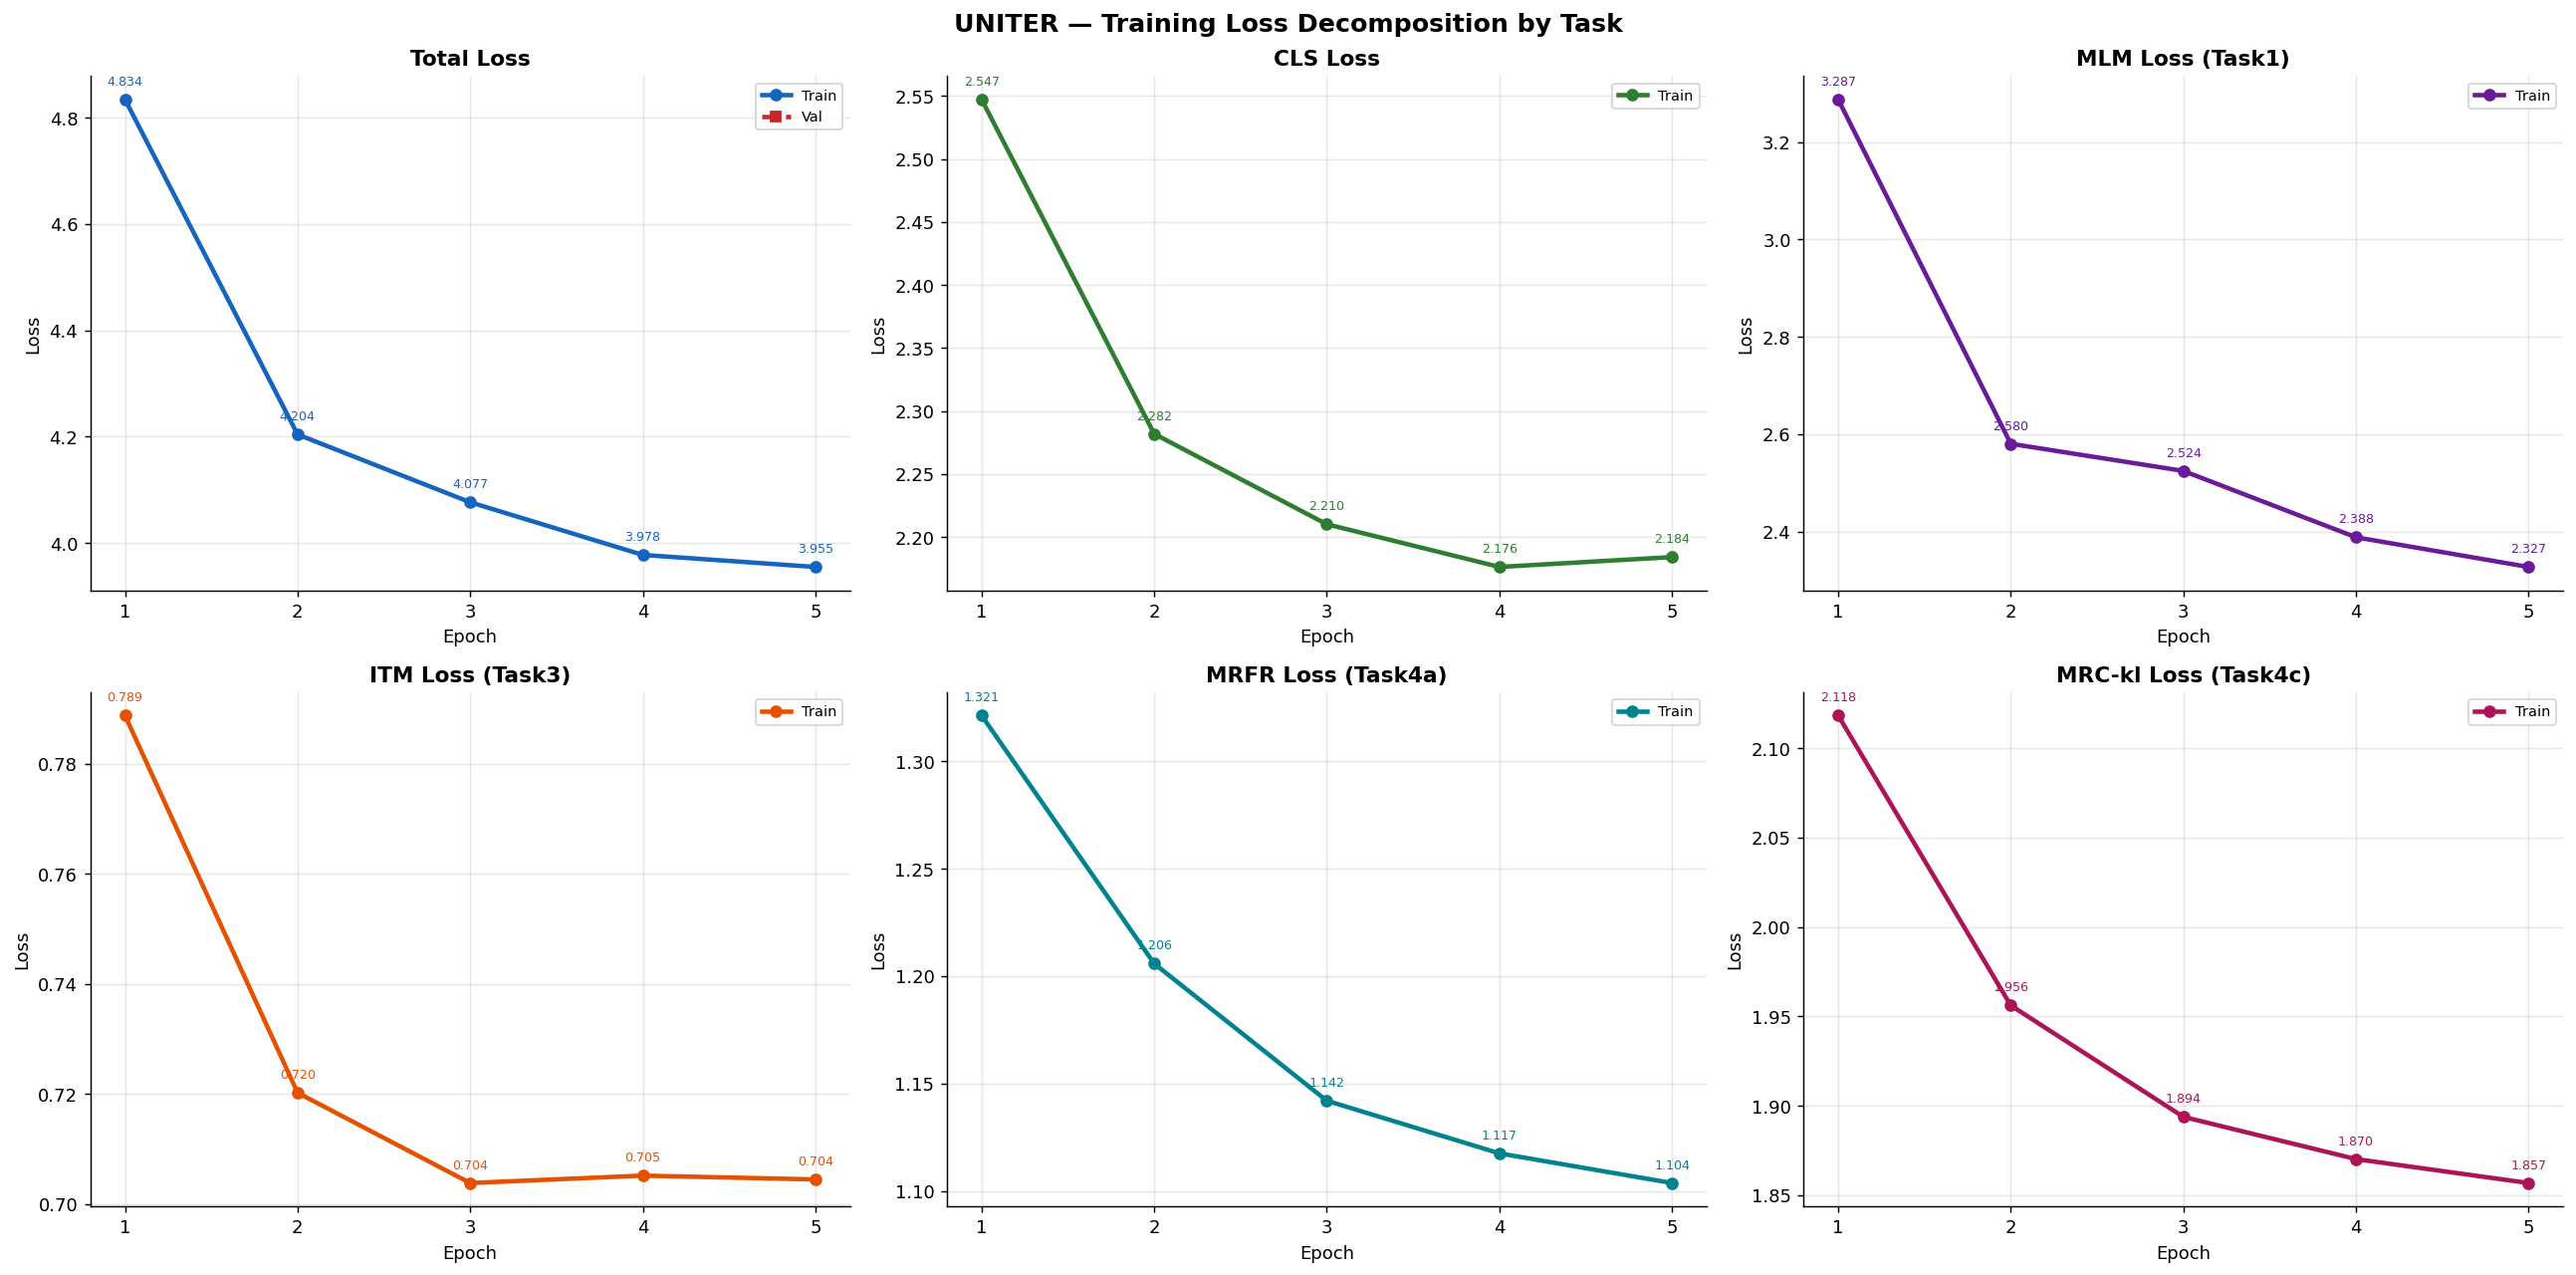

In [15]:
# ============================================================
# VISUALIZATION 1 — LOSS DECOMPOSITION (ALL 5 TASKS)
# ============================================================
# Shows each UNITER pre-training task loss independently.

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("UNITER — Training Loss Decomposition by Task",
             fontsize=14, fontweight="bold")
axes = axes.flat

task_specs = [
    ("tr_total",  "va_total", "Total Loss",      "#1565C0", "#C62828"),
    ("tr_cls",    None,       "CLS Loss",         "#2E7D32", None),
    ("tr_mlm",    None,       "MLM Loss (Task1)", "#6A1B9A", None),
    ("tr_itm",    None,       "ITM Loss (Task3)", "#E65100", None),
    ("tr_mrfr",   None,       "MRFR Loss (Task4a)","#00838F",None),
    ("tr_mrc_kl", None,       "MRC-kl Loss (Task4c)","#AD1457",None),
]

for ax, (tr_key, va_key, title, tc, vc) in zip(axes, task_specs):
    ax.plot(epochs_x, history[tr_key], "o-",
            color=tc, lw=2.5, label="Train")
    if va_key and va_key in history:
        ax.plot(epochs_x, history[va_key], "s--",
                color=vc, lw=2.5, label="Val")
    for i, v in enumerate(history[tr_key]):
        ax.annotate(f"{v:.3f}", (epochs_x[i], v),
                    xytext=(0, 8), textcoords="offset points",
                    fontsize=7, color=tc, ha="center")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_xticks(epochs_x); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("uniter_viz1_losses.png",
            dpi=150, bbox_inches="tight")
plt.show()

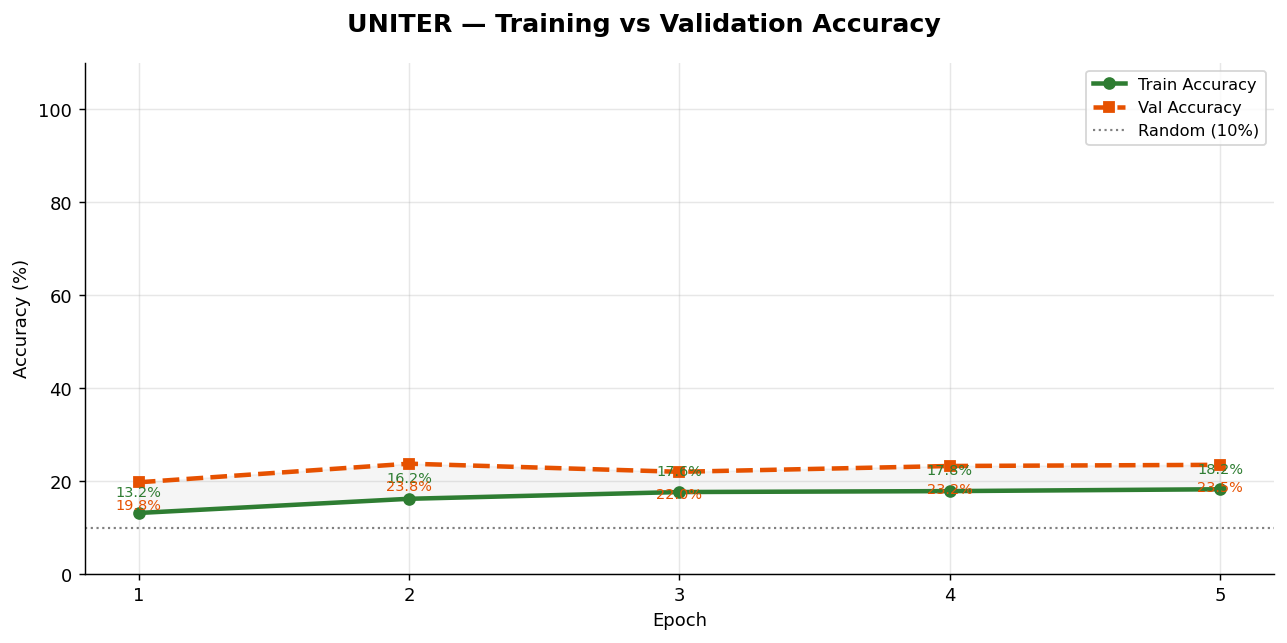

In [16]:
# ============================================================
# VISUALIZATION 2 — ACCURACY CURVES
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("UNITER — Training vs Validation Accuracy",
             fontsize=14, fontweight="bold")

ax.plot(epochs_x, history["tr_acc"], "o-",
        color="#2E7D32", lw=2.5, label="Train Accuracy")
ax.plot(epochs_x, history["va_acc"], "s--",
        color="#E65100", lw=2.5, label="Val Accuracy")
ax.axhline(10, color="gray", ls=":", lw=1.2,
           label="Random (10%)")
ax.fill_between(epochs_x, history["tr_acc"],
                history["va_acc"], alpha=0.08, color="gray")

for i, (ta, va) in enumerate(
        zip(history["tr_acc"], history["va_acc"])):
    ax.annotate(f"{ta:.1f}%", (epochs_x[i], ta),
                xytext=(0, 9), textcoords="offset points",
                fontsize=8, color="#2E7D32", ha="center")
    ax.annotate(f"{va:.1f}%", (epochs_x[i], va),
                xytext=(0, -15), textcoords="offset points",
                fontsize=8, color="#E65100", ha="center")

ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_xticks(epochs_x); ax.set_ylim(0, 110)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("uniter_viz2_accuracy.png",
            dpi=150, bbox_inches="tight")
plt.show()

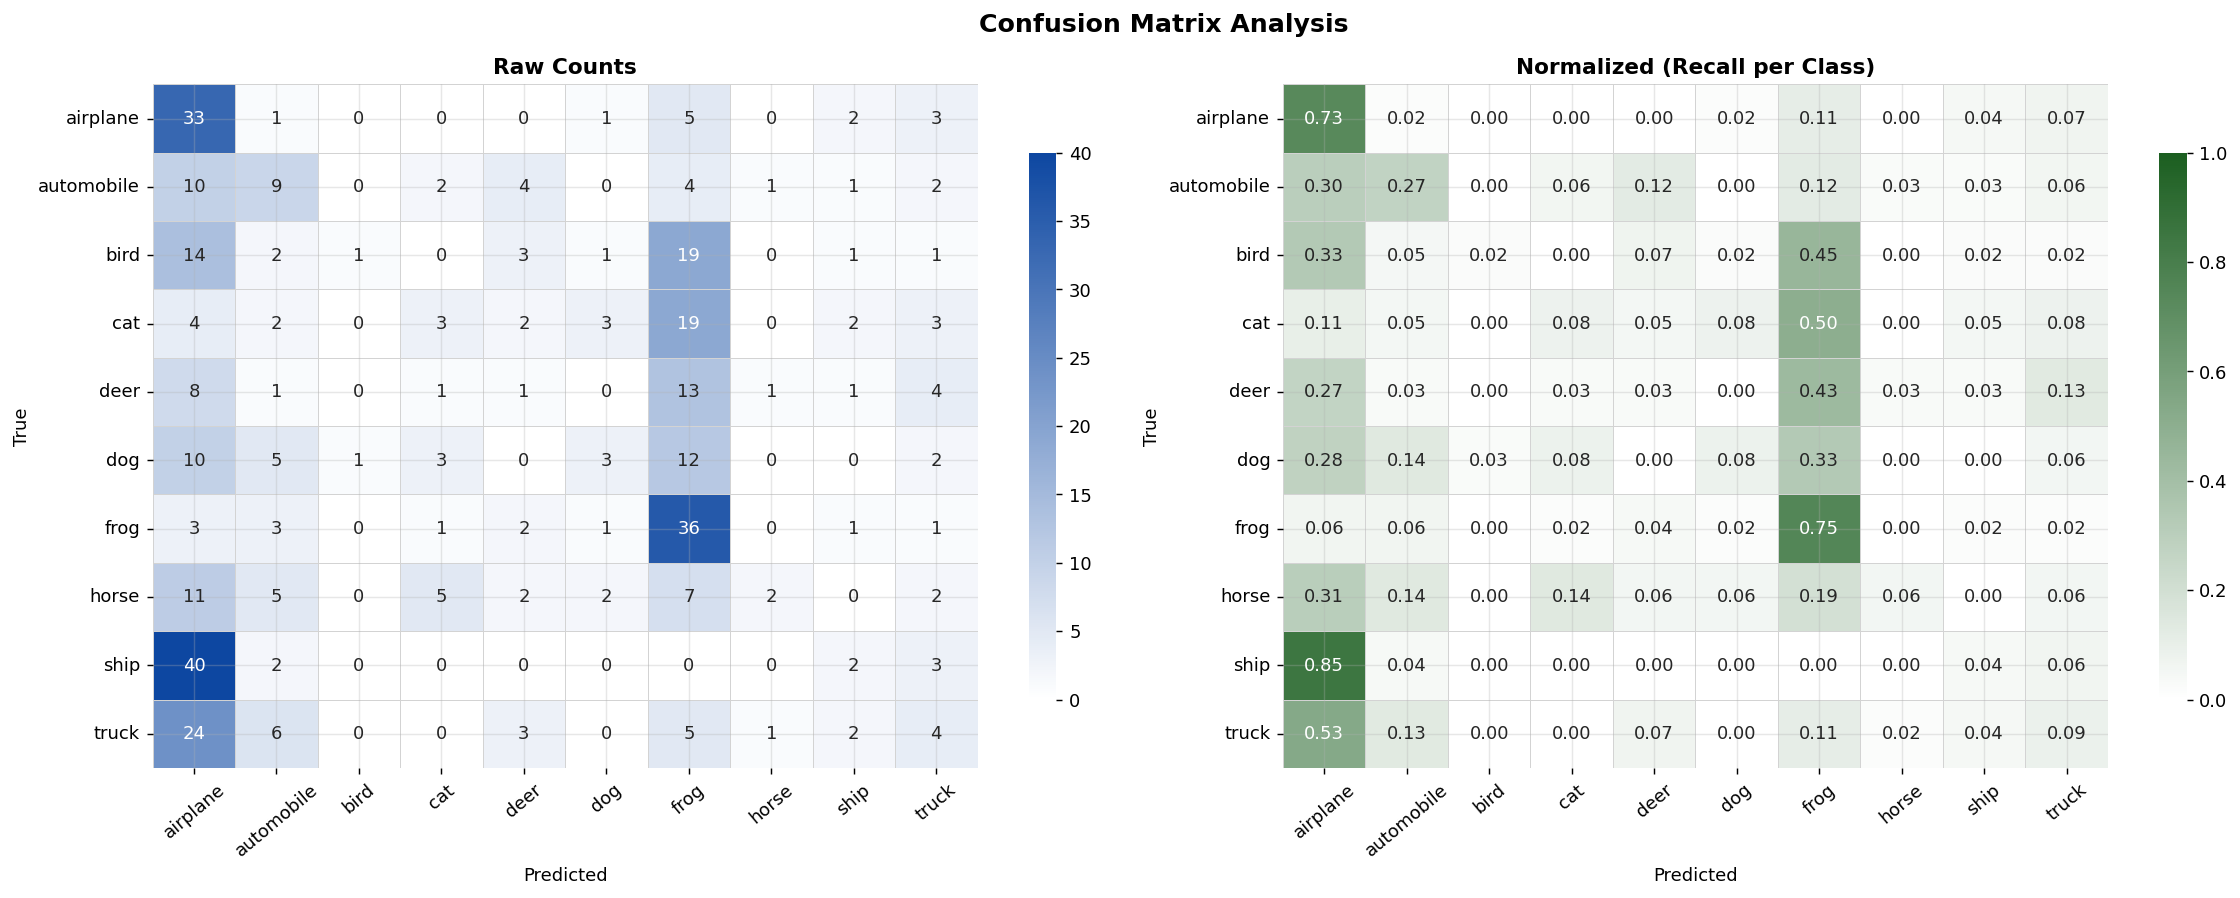

In [17]:
# ============================================================
# VISUALIZATION 3 — CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix Analysis",
             fontsize=14, fontweight="bold")

cmap_b = LinearSegmentedColormap.from_list(
    "bw", ["#FFFFFF", "#0D47A1"])
cmap_g = LinearSegmentedColormap.from_list(
    "gw", ["#FFFFFF", "#1B5E20"])

sns.heatmap(cm, annot=True, fmt="d", cmap=cmap_b,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title("Raw Counts", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=40)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap=cmap_g,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, vmin=0, vmax=1,
            ax=axes[1])
axes[1].set_title("Normalized (Recall per Class)",
                  fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("uniter_viz3_confusion.png",
            dpi=150, bbox_inches="tight")
plt.show()

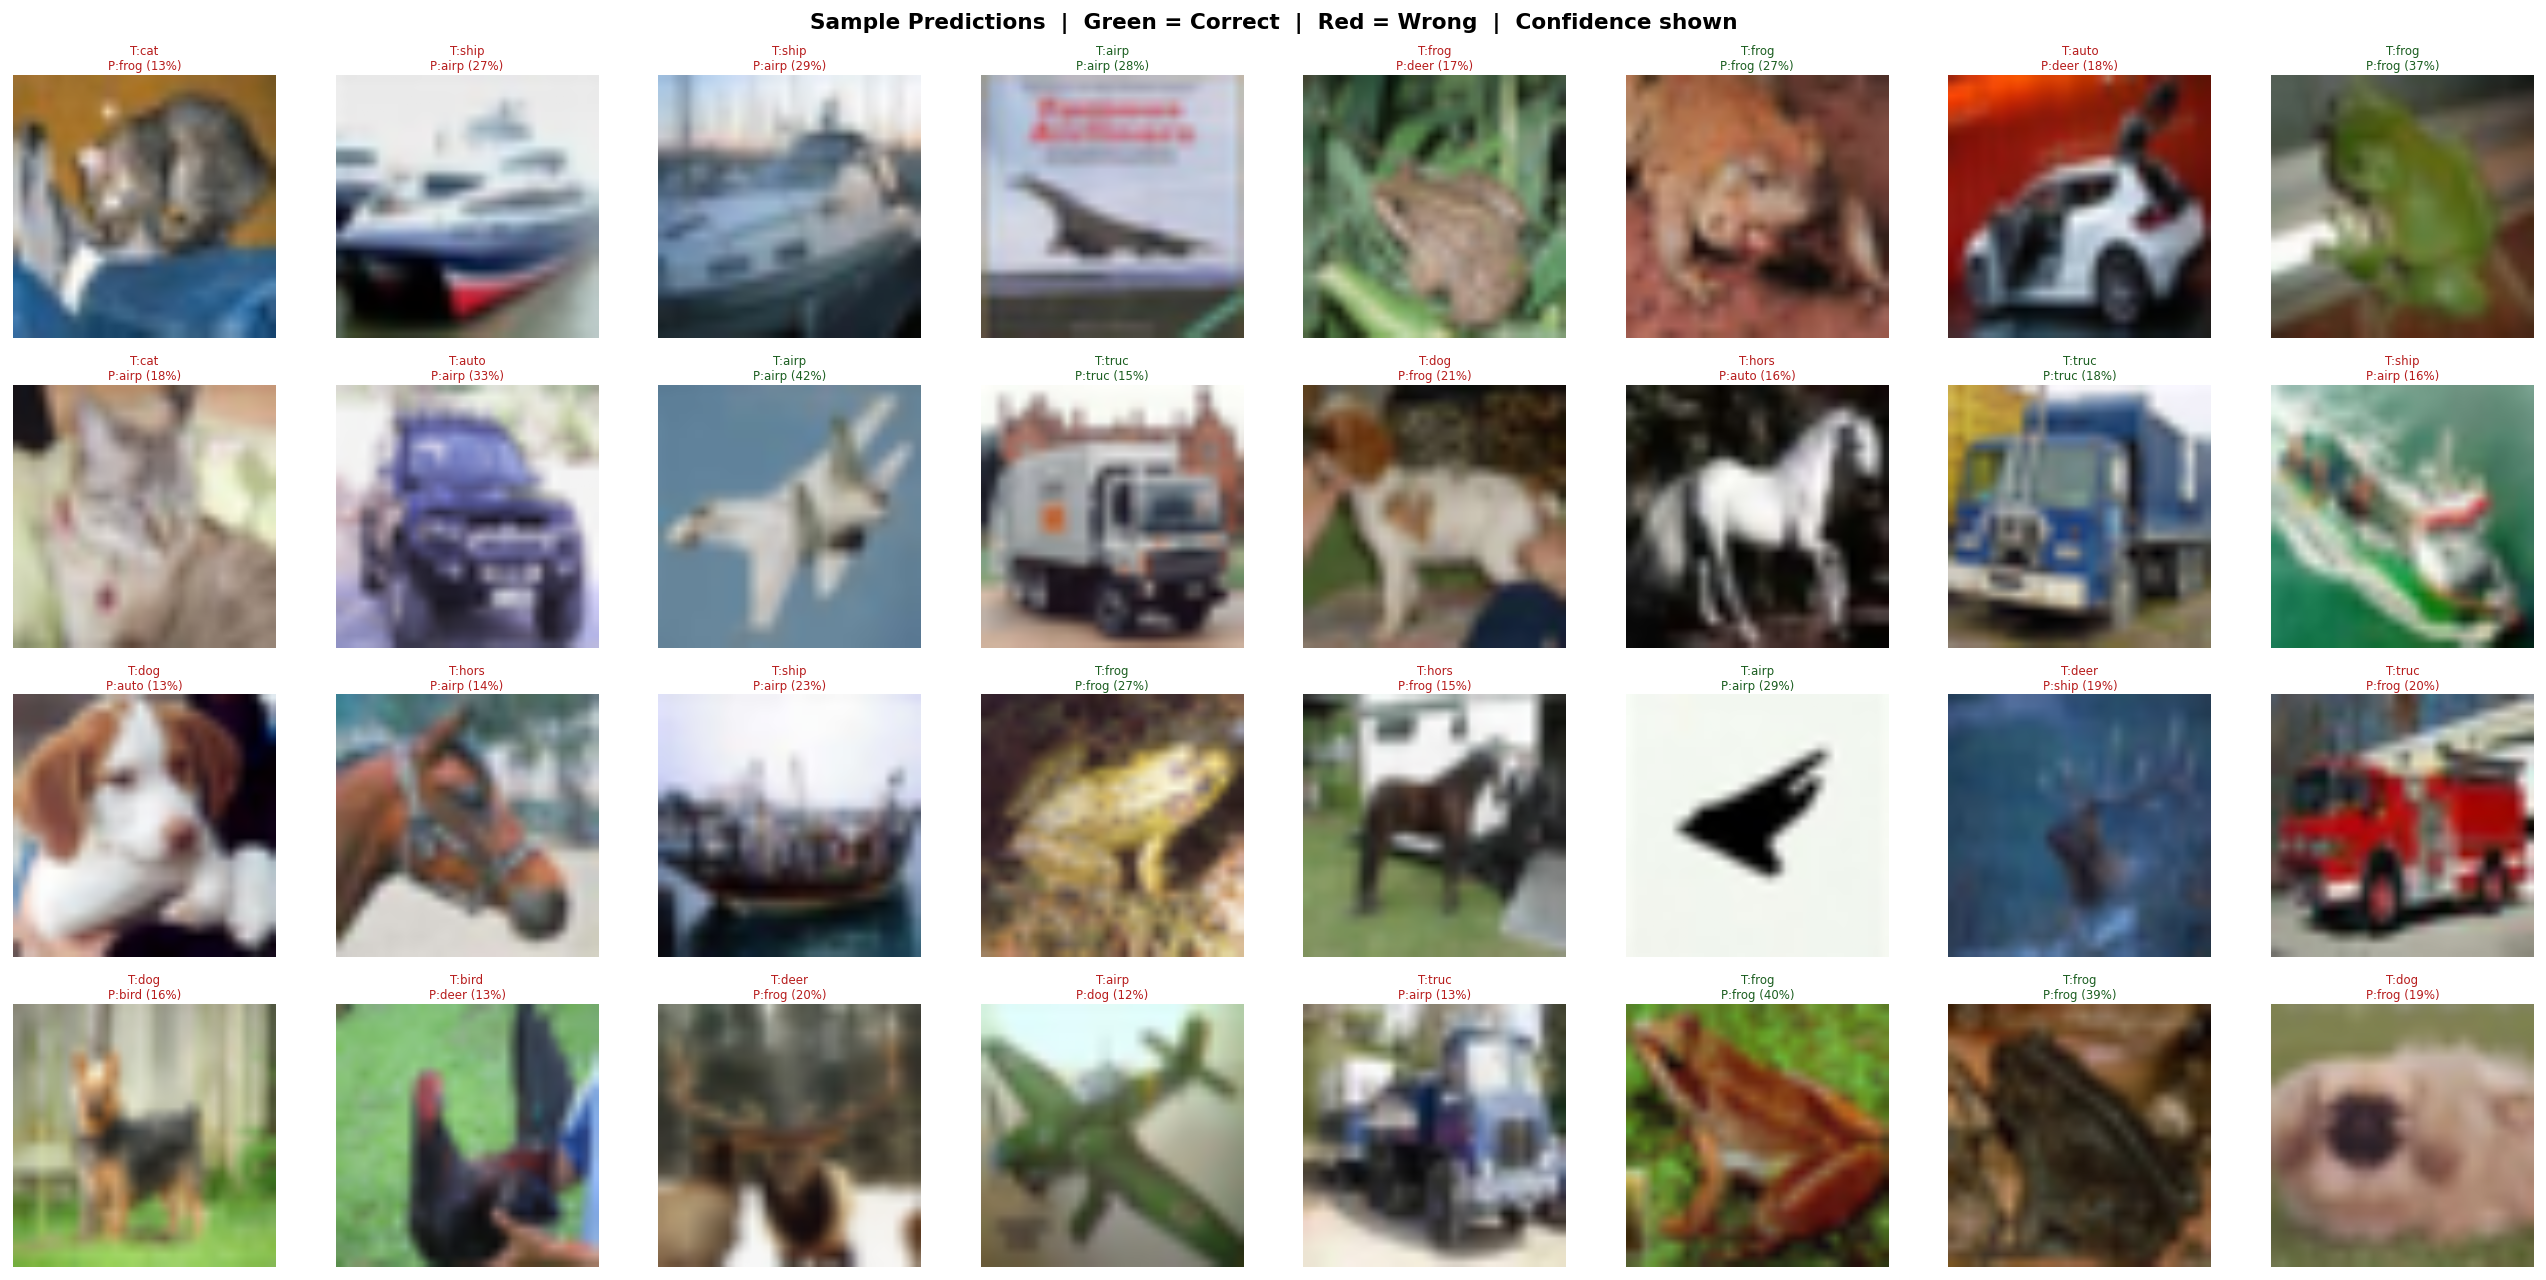

In [18]:
# ============================================================
# VISUALIZATION 4 — SAMPLE PREDICTIONS GRID
# ============================================================

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle(
    "Sample Predictions  |  Green = Correct  |  "
    "Red = Wrong  |  Confidence shown",
    fontsize=12, fontweight="bold")

for idx, ax in enumerate(axes.flat):
    if idx >= len(s_imgs):
        ax.axis("off"); continue
    ax.imshow(denorm(s_imgs[idx]).permute(1, 2, 0).numpy(),
              interpolation="bilinear")
    ax.axis("off")
    correct = (s_labels[idx] == s_preds[idx])
    col     = "#1B5E20" if correct else "#B71C1C"
    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(col)
        ax.spines[spine].set_linewidth(3)
    ax.set_title(
        f"T:{CIFAR10_CLASSES[s_labels[idx]][:4]}\n"
        f"P:{CIFAR10_CLASSES[s_preds[idx]][:4]} "
        f"({s_confs[idx]*100:.0f}%)",
        fontsize=6.5, color=col, pad=3)

plt.tight_layout()
plt.savefig("uniter_viz4_predictions.png",
            dpi=150, bbox_inches="tight")
plt.show()

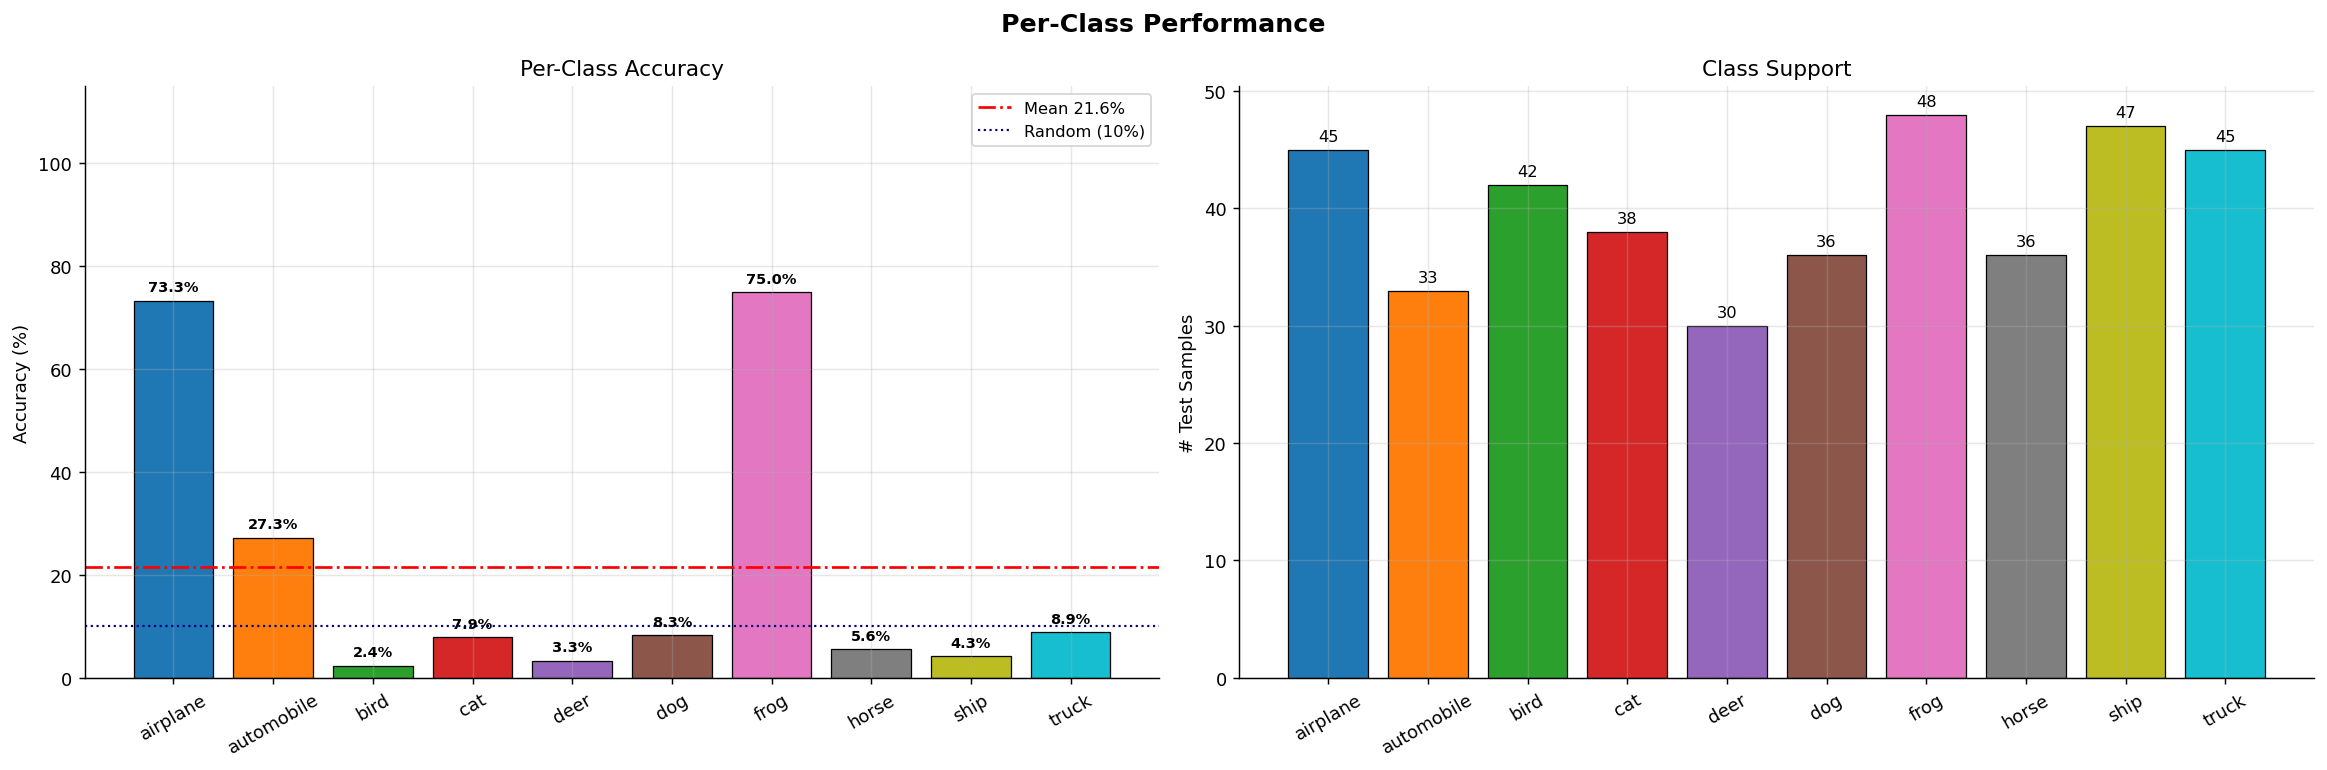

In [19]:
# ============================================================
# VISUALIZATION 5 — PER-CLASS ACCURACY & SUPPORT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Per-Class Performance",
             fontsize=14, fontweight="bold")

ax  = axes[0]
brs = ax.bar(CIFAR10_CLASSES, per_cls_acc,
             color=CLASS_COLORS,
             edgecolor="black", lw=0.7)
ax.axhline(np.mean(per_cls_acc), color="red",
           ls="-.", lw=1.5,
           label=f"Mean {np.mean(per_cls_acc):.1f}%")
ax.axhline(10, color="navy", ls=":", lw=1.2,
           label="Random (10%)")
for b, a in zip(brs, per_cls_acc):
    ax.text(b.get_x() + b.get_width()/2, a + 1.2,
            f"{a:.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold")
ax.set_ylim(0, 115); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy")
ax.tick_params(axis="x", rotation=30); ax.legend(fontsize=9)

ax = axes[1]
support = [cm[c].sum() for c in range(NUM_CLASSES)]
ax.bar(CIFAR10_CLASSES, support,
       color=CLASS_COLORS, edgecolor="black", lw=0.7)
for i, s in enumerate(support):
    ax.text(i, s + 0.5, str(s),
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("# Test Samples")
ax.set_title("Class Support")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("uniter_viz5_perclass.png",
            dpi=150, bbox_inches="tight")
plt.show()

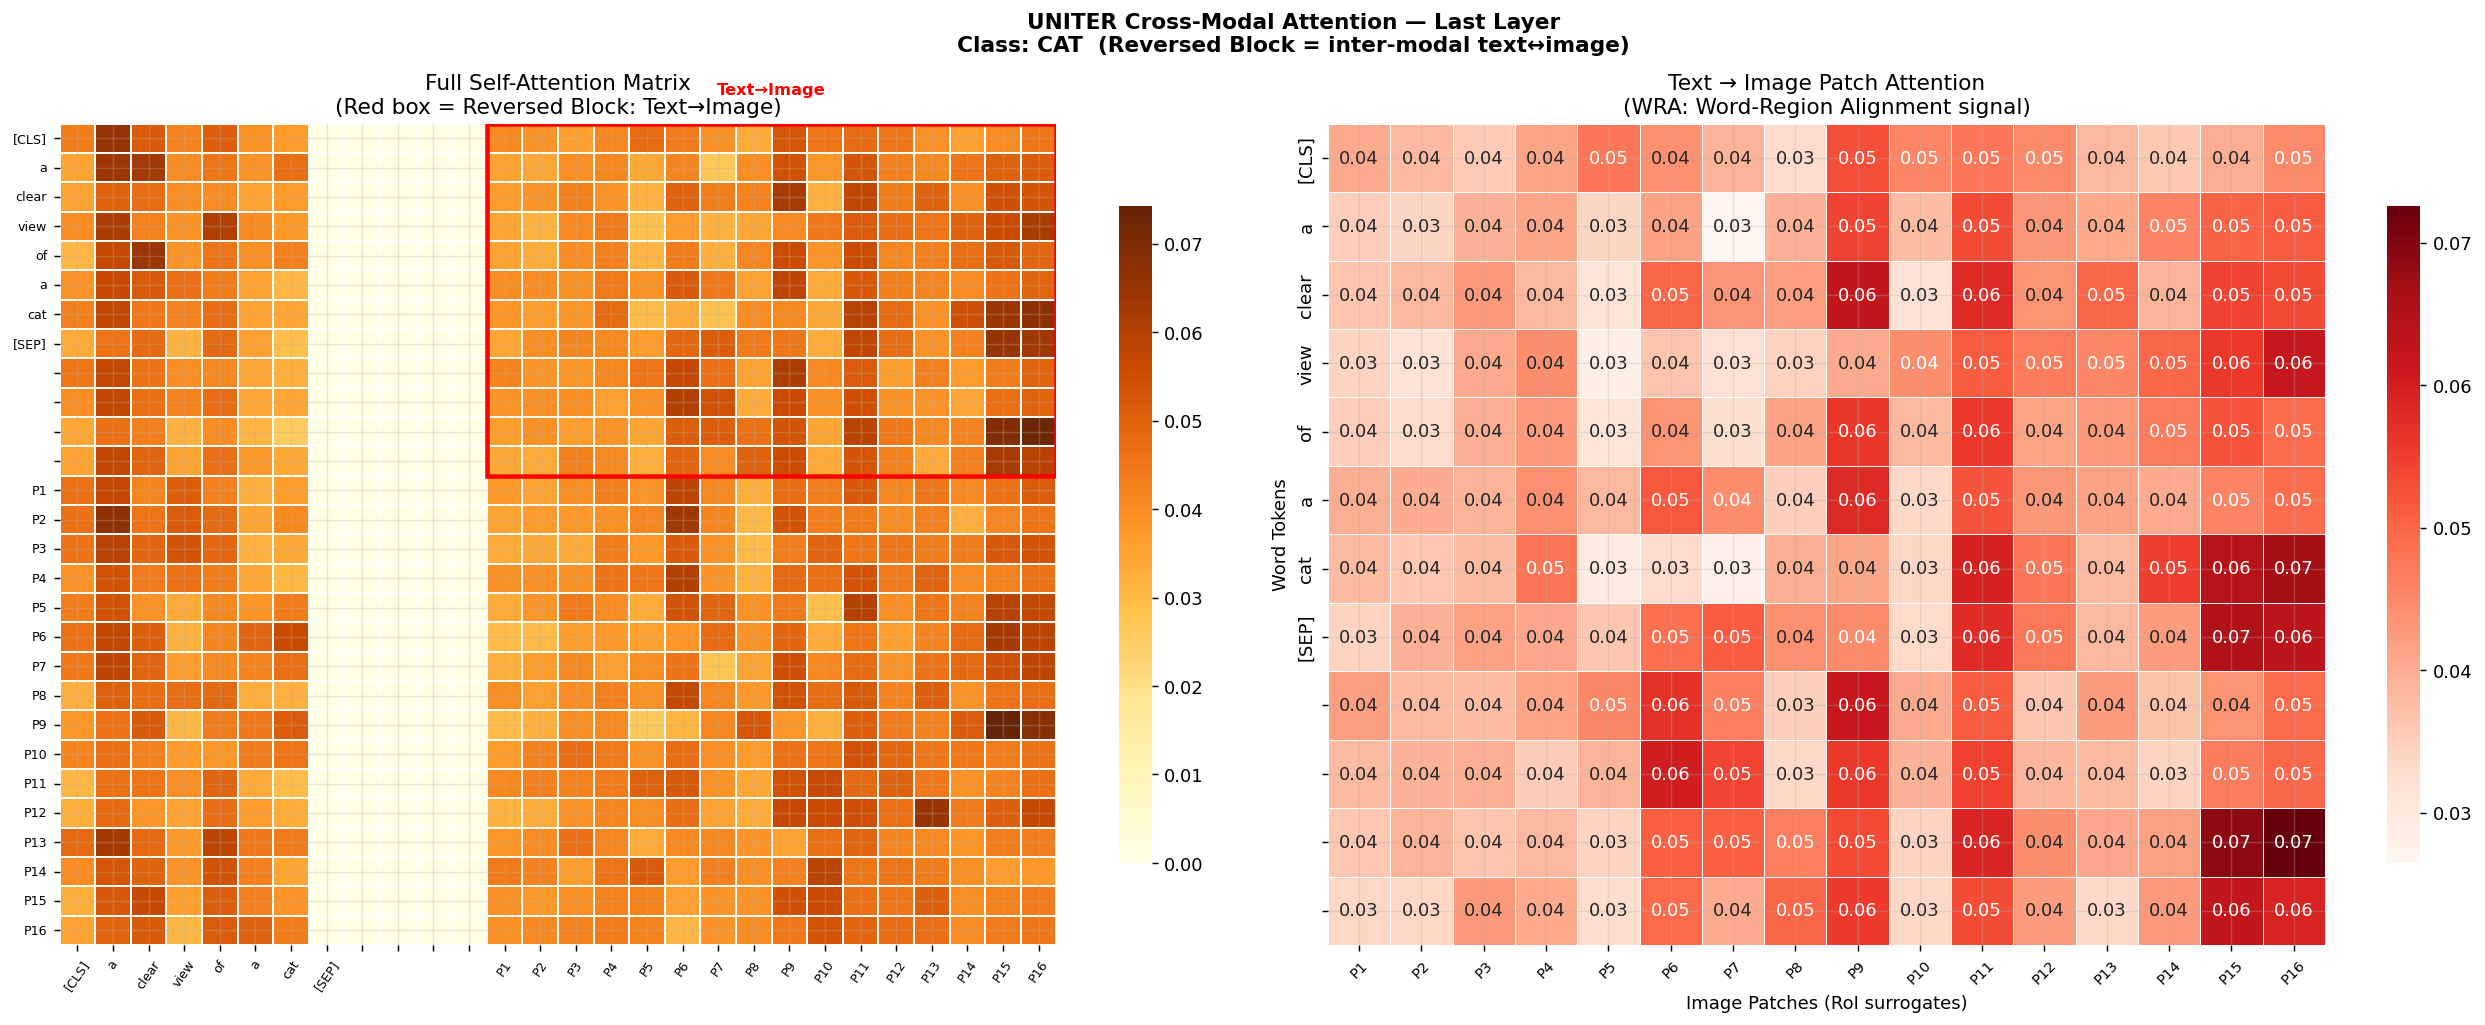

In [20]:
# ============================================================
# VISUALIZATION 6 — CROSS-MODAL ATTENTION HEATMAP
# ============================================================
# UNITER paper (Fig.2) identifies 6 attention patterns:
# Vertical, Diagonal, Vertical+Diagonal, Block (intra-modal),
# Heterogeneous, Reversed Block (inter-modal text↔image).
# We visualize the last-layer averaged attention for one sample.

model.eval()
with torch.no_grad():
    sample_img   = s_imgs[0].unsqueeze(0).to(DEVICE)
    sample_label = s_labels[0]
    sample_tok   = caption_to_tokens(sample_label)\
                       .unsqueeze(0).to(DEVICE)
    (_, attn_all, _, _, _, _, _) = model(
        sample_img, sample_tok,
        return_attn=True, return_pretrain=False)

last_attn_avg = attn_all[-1][0].mean(0).cpu().numpy()
L_v = MAX_TEXT_LEN; P_v = N_PATCHES
caption_w = (["[CLS]"] +
             random.choice(CAPTION_TEMPLATES)
             .format(CIFAR10_CLASSES[sample_label]).split() +
             ["[SEP]"])
caption_w = caption_w[:L_v]
caption_w += [""] * (L_v - len(caption_w))
all_labels_v = caption_w + [f"P{j+1}" for j in range(P_v)]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    f"UNITER Cross-Modal Attention — Last Layer\n"
    f"Class: {CIFAR10_CLASSES[sample_label].upper()}  "
    f"(Reversed Block = inter-modal text↔image)",
    fontsize=12, fontweight="bold")

ax = axes[0]
sns.heatmap(last_attn_avg, cmap="YlOrBr",
            xticklabels=all_labels_v,
            yticklabels=all_labels_v,
            ax=ax, cbar_kws={"shrink": 0.8},
            linewidths=0.2, linecolor="white")
ax.set_title("Full Self-Attention Matrix\n"
             "(Red box = Reversed Block: Text→Image)")
ax.tick_params(axis="x", rotation=55, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
ax.add_patch(mpatches.Rectangle(
    (L_v, 0), P_v, L_v,
    fill=False, edgecolor="red", lw=2.5, zorder=5))
ax.text(L_v + P_v/2, -1.0, "Text→Image",
        ha="center", color="red",
        fontsize=9, fontweight="bold")

ax = axes[1]
text2img = last_attn_avg[:L_v, L_v:]
sns.heatmap(text2img, cmap="Reds",
            xticklabels=[f"P{j+1}" for j in range(P_v)],
            yticklabels=caption_w,
            ax=ax, annot=True, fmt=".2f",
            cbar_kws={"shrink": 0.8},
            linewidths=0.3, linecolor="white")
ax.set_title("Text → Image Patch Attention\n"
             "(WRA: Word-Region Alignment signal)")
ax.set_xlabel("Image Patches (RoI surrogates)")
ax.set_ylabel("Word Tokens")
ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig("uniter_viz6_attention.png",
            dpi=150, bbox_inches="tight")
plt.show()

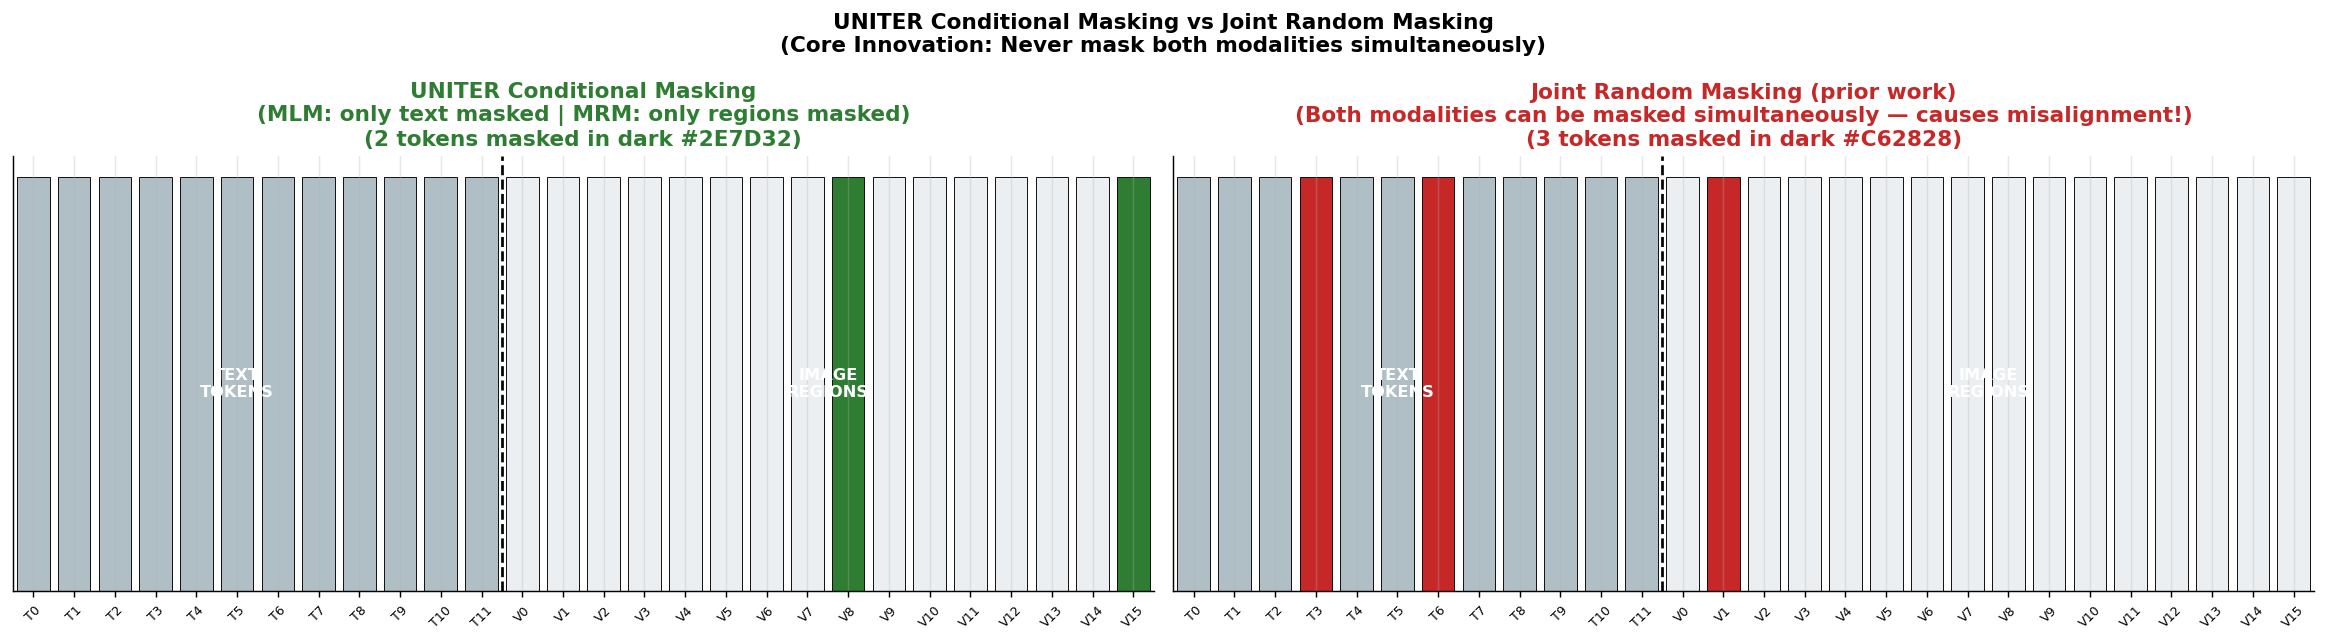

In [21]:
# ============================================================
# VISUALIZATION 7 — CONDITIONAL MASKING ANALYSIS
# ============================================================
# Illustrates UNITER's key innovation: conditional vs joint masking.
# Shows which tokens are masked in each strategy for one sample.

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    "UNITER Conditional Masking vs Joint Random Masking\n"
    "(Core Innovation: Never mask both modalities simultaneously)",
    fontsize=12, fontweight="bold")

sample_toks = caption_to_tokens(s_labels[0])

# Conditional masking: only text masked
cond_masked, _ = apply_conditional_mlm(sample_toks)
cond_region     = apply_conditional_mrm(N_PATCHES)

# Joint masking simulation: both can be masked simultaneously
joint_tok_mask  = torch.rand(MAX_TEXT_LEN) < 0.15
joint_reg_mask  = torch.rand(N_PATCHES)    < 0.15

for ax, (tok_mask, reg_mask, title, color) in zip(axes, [
    (cond_masked != sample_toks, cond_region,
     "UNITER Conditional Masking\n"
     "(MLM: only text masked | MRM: only regions masked)",
     "#2E7D32"),
    (joint_tok_mask, joint_reg_mask,
     "Joint Random Masking (prior work)\n"
     "(Both modalities can be masked simultaneously — causes misalignment!)",
     "#C62828"),
]):
    # Show token mask
    tok_vis = tok_mask.float().numpy()
    reg_vis = reg_mask.float().numpy()
    x_pos   = list(range(MAX_TEXT_LEN)) + \
               list(range(MAX_TEXT_LEN, MAX_TEXT_LEN + N_PATCHES))
    colors  = ([color if m else "#B0BEC5"
                for m in tok_vis] +
               [color if m else "#ECEFF1"
                for m in reg_vis])
    labels  = ([f"T{i}" for i in range(MAX_TEXT_LEN)] +
               [f"V{j}" for j in range(N_PATCHES)])
    ax.bar(x_pos, [1] * len(x_pos), color=colors,
           edgecolor="black", lw=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=45, fontsize=7)
    ax.axvline(MAX_TEXT_LEN - 0.5, color="black",
               ls="--", lw=1.5)
    ax.text(MAX_TEXT_LEN/2 - 1, 0.5, "TEXT\nTOKENS",
            ha="center", va="center", fontsize=9,
            fontweight="bold", color="white")
    ax.text(MAX_TEXT_LEN + N_PATCHES/2 - 0.5, 0.5,
            "IMAGE\nREGIONS",
            ha="center", va="center", fontsize=9,
            fontweight="bold", color="white")
    masked_count = tok_vis.sum() + reg_vis.sum()
    ax.set_title(f"{title}\n"
                 f"({int(masked_count)} tokens masked in dark {color})",
                 fontweight="bold", color=color)
    ax.set_yticks([])
    ax.set_xlim(-0.5, len(x_pos) - 0.5)

plt.tight_layout()
plt.savefig("uniter_viz7_masking.png",
            dpi=150, bbox_inches="tight")
plt.show()

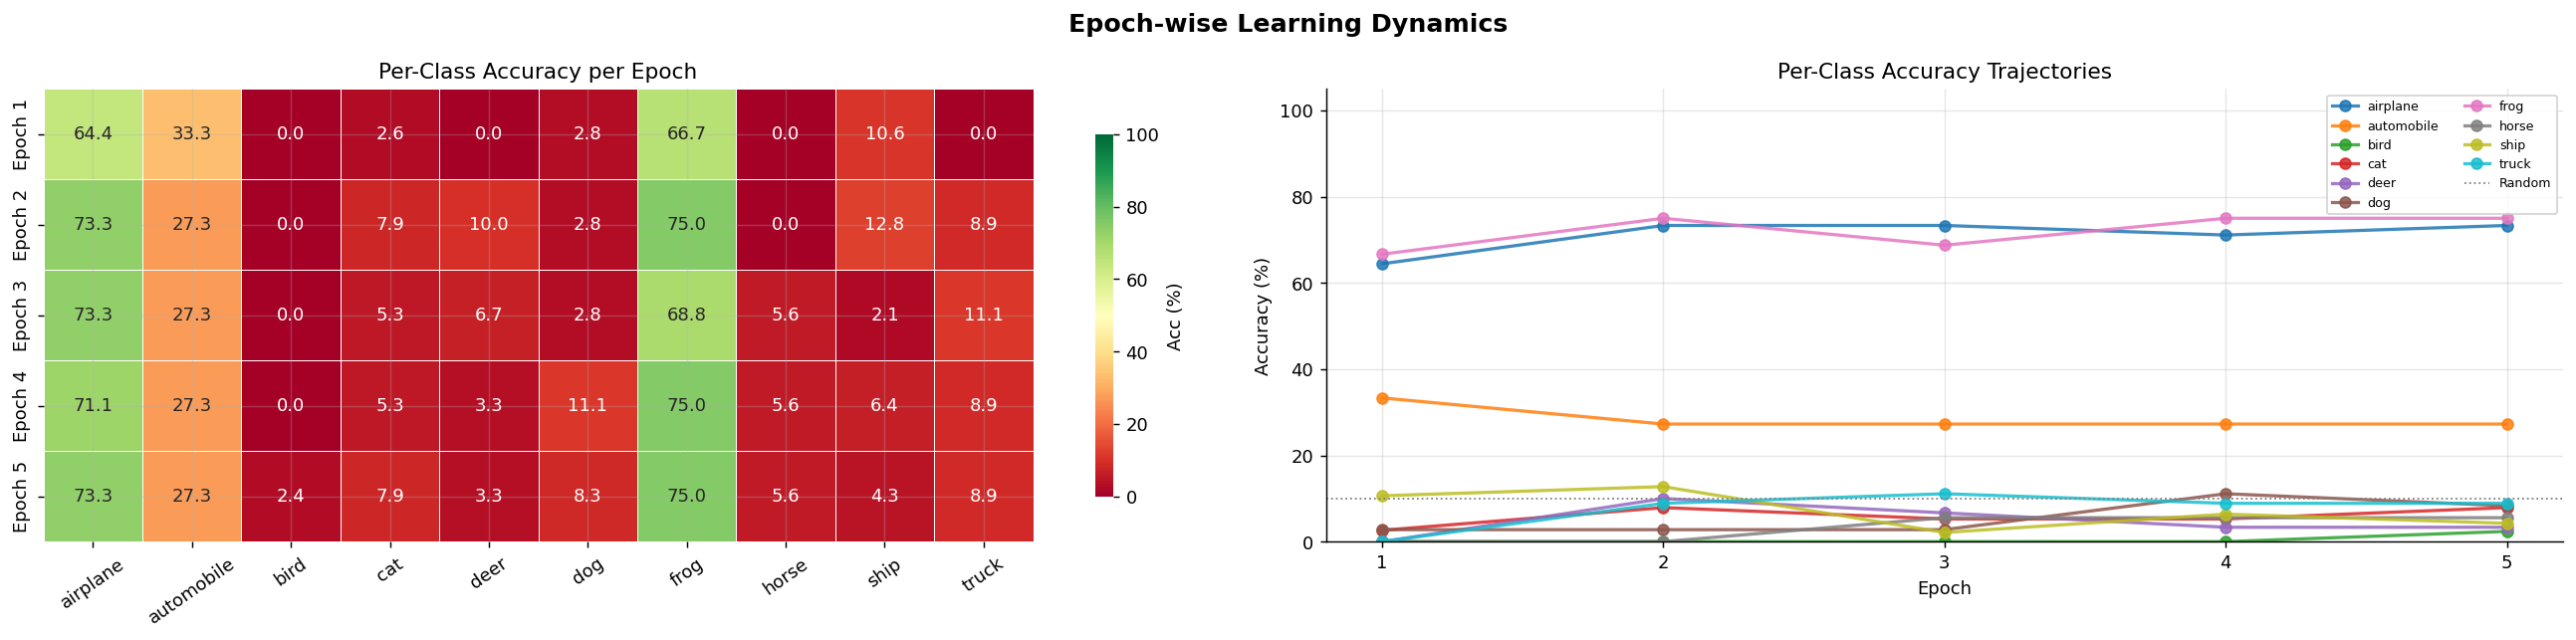

In [22]:
# ============================================================
# VISUALIZATION 8 — EPOCH-WISE CLASS ACCURACY HEATMAP
# ============================================================

epoch_cls_acc = np.zeros((NUM_EPOCHS, NUM_CLASSES))
for ep in range(NUM_EPOCHS):
    cm_ep = confusion_matrix(
        history["v_lbls"][ep], history["v_preds"][ep],
        labels=list(range(NUM_CLASSES)))
    for c in range(NUM_CLASSES):
        if cm_ep[c].sum():
            epoch_cls_acc[ep, c] = (
                100 * cm_ep[c, c] / cm_ep[c].sum())

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle("Epoch-wise Learning Dynamics",
             fontsize=14, fontweight="bold")

sns.heatmap(epoch_cls_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"Epoch {e}"
                         for e in range(1, NUM_EPOCHS+1)],
            annot=True, fmt=".1f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Acc (%)", "shrink": 0.8},
            ax=axes[0])
axes[0].set_title("Per-Class Accuracy per Epoch")
axes[0].tick_params(axis="x", rotation=35)

ax = axes[1]
for c in range(NUM_CLASSES):
    ax.plot(range(1, NUM_EPOCHS+1), epoch_cls_acc[:, c],
            "o-", lw=1.8, color=CLASS_COLORS[c],
            label=CIFAR10_CLASSES[c], alpha=0.85)
ax.axhline(10, color="gray", ls=":", lw=1, label="Random")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy Trajectories")
ax.set_xticks(range(1, NUM_EPOCHS+1))
ax.legend(fontsize=7, ncol=2); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("uniter_viz8_epoch_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

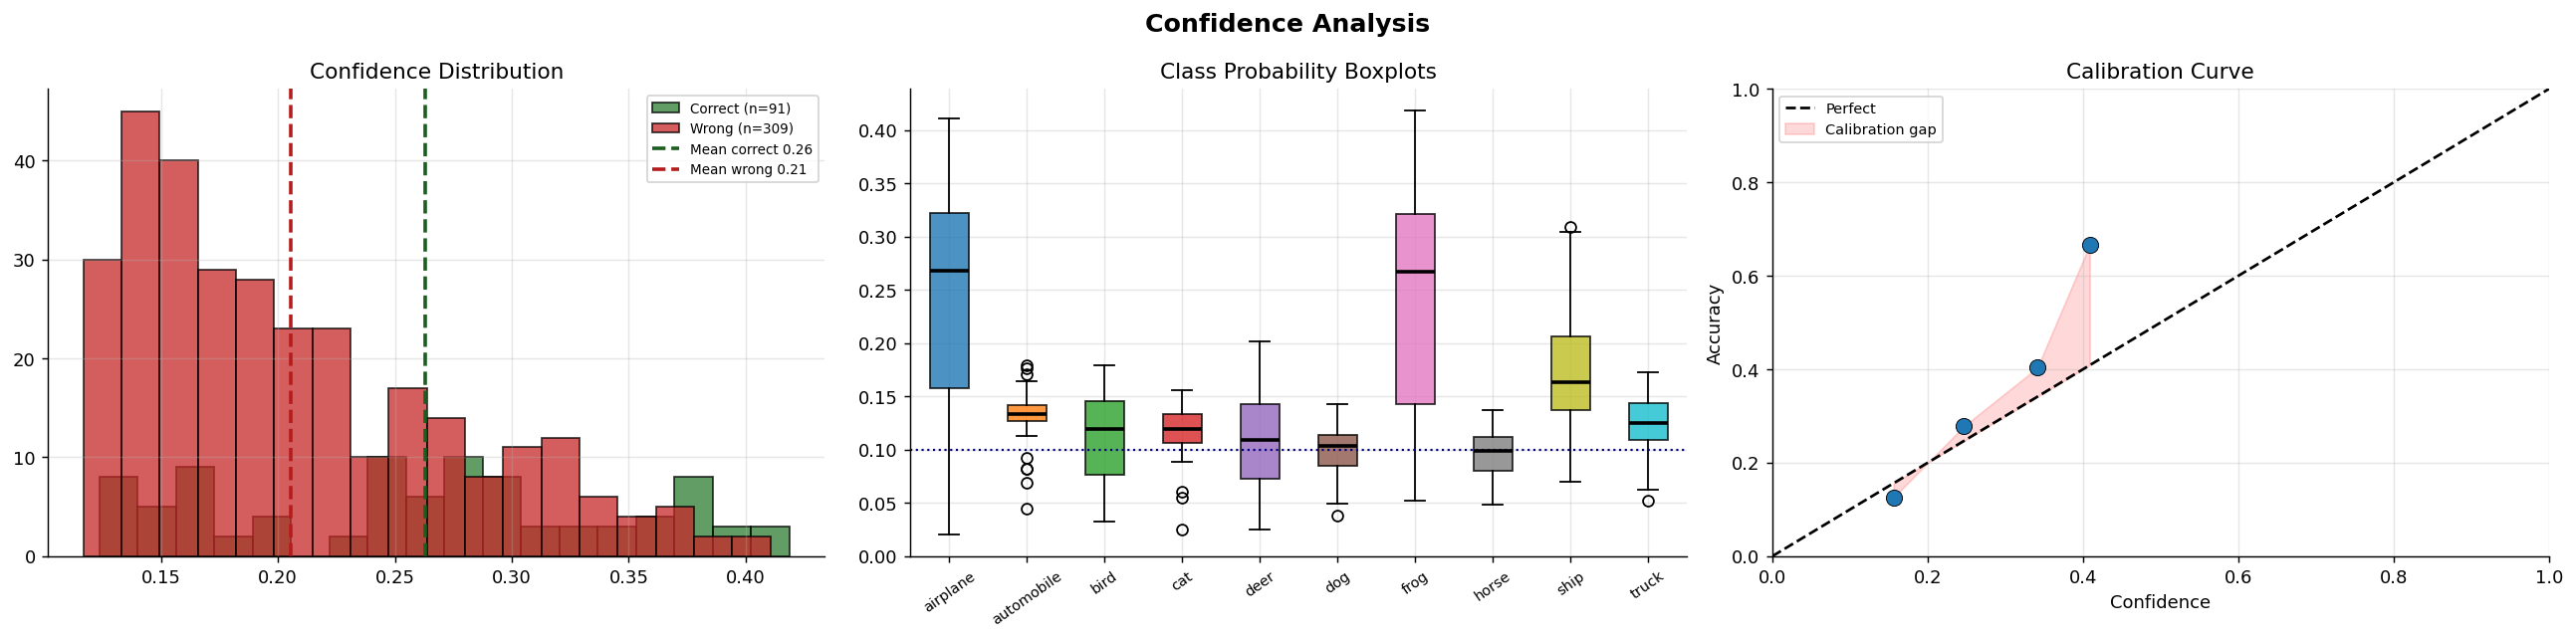

In [23]:
# ============================================================
# VISUALIZATION 9 — CONFIDENCE ANALYSIS
# ============================================================

model.eval()
confs_correct, confs_wrong = [], []
probs_matrix = np.zeros((SUBSET_TEST, NUM_CLASSES))
ptr = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        toks   = torch.stack([
            caption_to_tokens(lbl.item())
            for lbl in labels]).to(DEVICE)
        (cls_logits, _, _, _, _, _, _) = model(imgs, toks)
        probs  = F.softmax(cls_logits, dim=1).cpu().numpy()
        preds  = probs.argmax(1)
        bs     = imgs.size(0)
        probs_matrix[ptr:ptr+bs] = probs
        ptr += bs
        for i in range(bs):
            conf = probs[i].max()
            if preds[i] == labels[i].item():
                confs_correct.append(conf)
            else:
                confs_wrong.append(conf)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Confidence Analysis",
             fontsize=14, fontweight="bold")

ax = axes[0]
ax.hist(confs_correct, bins=18, color="#2E7D32", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Correct (n={len(confs_correct)})")
ax.hist(confs_wrong, bins=18, color="#C62828", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Wrong (n={len(confs_wrong)})")
ax.axvline(np.mean(confs_correct), color="#1B5E20",
           ls="--", lw=2,
           label=f"Mean correct {np.mean(confs_correct):.2f}")
ax.axvline(np.mean(confs_wrong), color="#B71C1C",
           ls="--", lw=2,
           label=f"Mean wrong {np.mean(confs_wrong):.2f}")
ax.set_title("Confidence Distribution"); ax.legend(fontsize=7.5)

ax = axes[1]
box_data = [
    probs_matrix[
        [i for i, l in enumerate(final_labels) if l == c], c
    ].tolist()
    for c in range(NUM_CLASSES)
]
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color="black", lw=2))
for patch, col in zip(bp["boxes"], CLASS_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, fontsize=8)
ax.set_title("Class Probability Boxplots")
ax.axhline(0.1, color="navy", ls=":", lw=1.2)

ax = axes[2]
bins_conf    = np.linspace(0, 1, 11)
all_confs_a  = probs_matrix.max(1)
all_correct  = (probs_matrix.argmax(1) ==
                np.array(final_labels[:ptr])).astype(float)
bin_acc, bin_conf_means = [], []
for lo, hi in zip(bins_conf[:-1], bins_conf[1:]):
    mask = (all_confs_a >= lo) & (all_confs_a < hi)
    if mask.sum():
        bin_acc.append(all_correct[mask].mean())
        bin_conf_means.append(all_confs_a[mask].mean())
ax.plot([0,1],[0,1],"k--", lw=1.5, label="Perfect")
ax.scatter(bin_conf_means, bin_acc, s=80, zorder=5,
           edgecolors="black", lw=0.5)
ax.fill_between(bin_conf_means, bin_acc, bin_conf_means,
                alpha=0.15, color="red",
                label="Calibration gap")
ax.set_title("Calibration Curve")
ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("uniter_viz9_confidence.png",
            dpi=150, bbox_inches="tight")
plt.show()

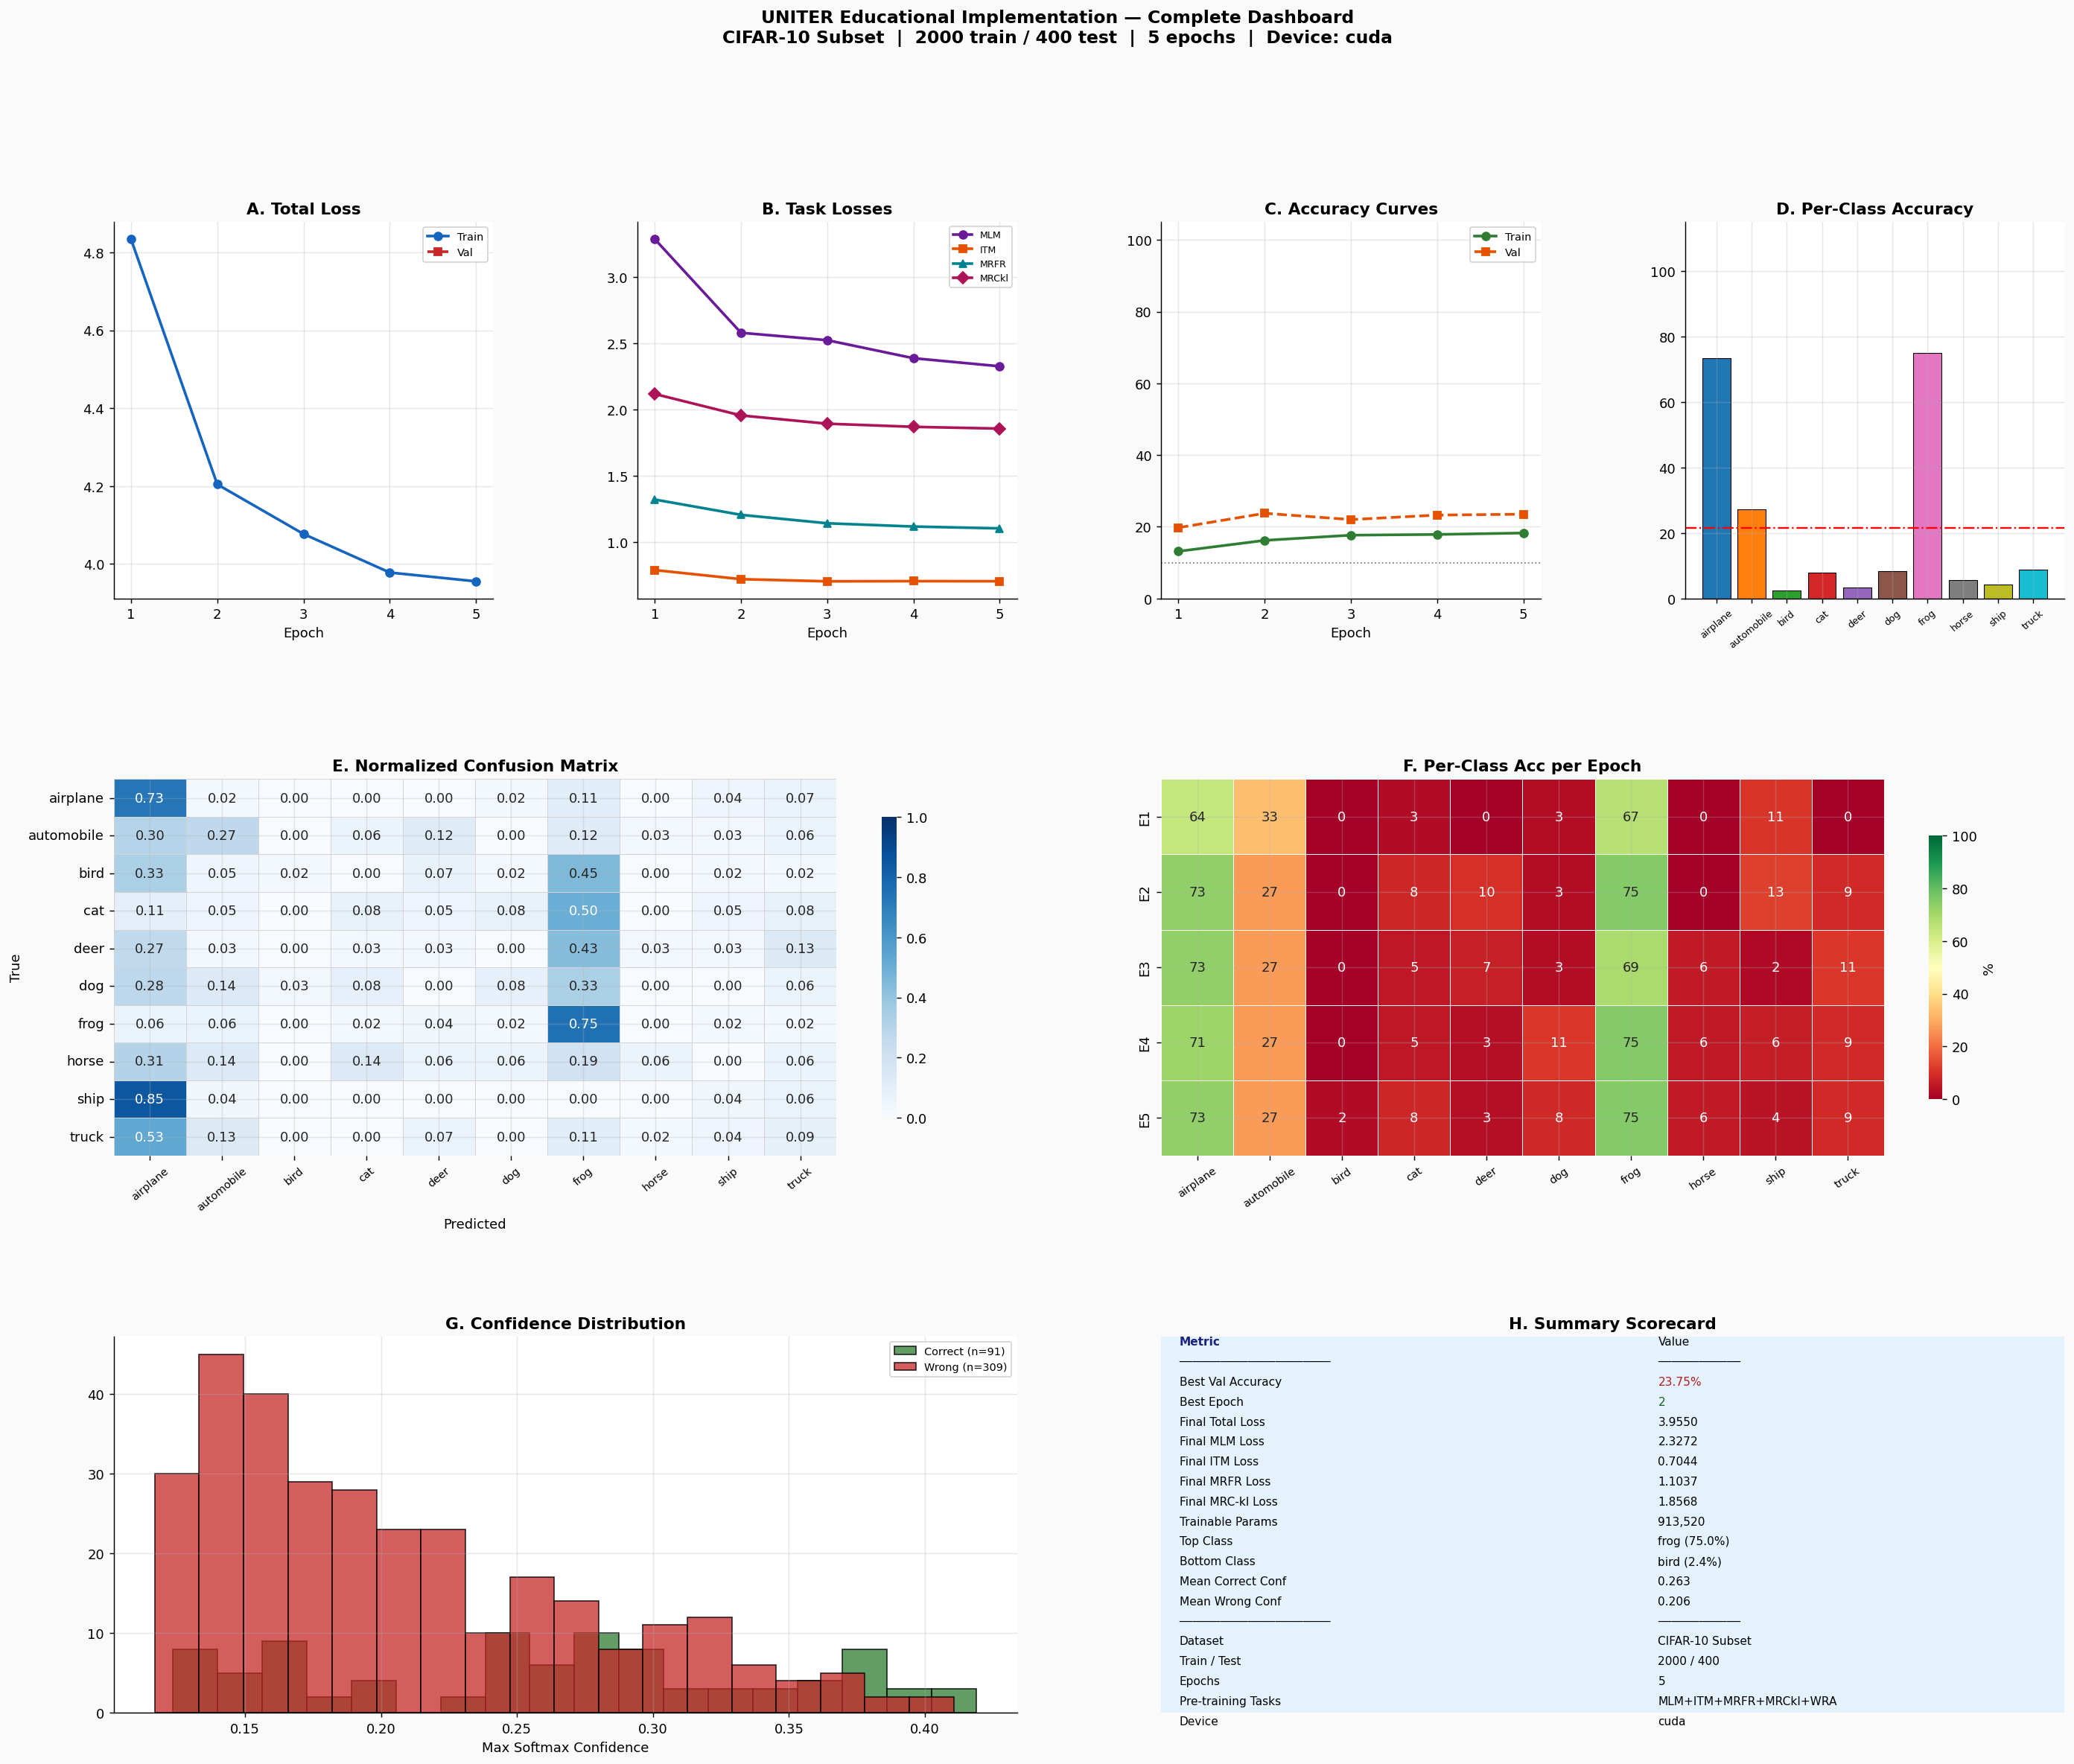

All 10 visualizations saved.


In [24]:
# ============================================================
# VISUALIZATION 10 — COMPLETE RESULTS DASHBOARD
# ============================================================

fig = plt.figure(figsize=(26, 20))
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "UNITER Educational Implementation — Complete Dashboard\n"
    f"CIFAR-10 Subset  |  {SUBSET_TRAIN} train / "
    f"{SUBSET_TEST} test  |  {NUM_EPOCHS} epochs  |  "
    f"Device: {DEVICE}",
    fontsize=13, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.48, wspace=0.38)

# A: Total Loss
ax = fig.add_subplot(gs[0, 0])
ax.plot(epochs_x, history["tr_total"], "o-",
        color="#1565C0", lw=2, label="Train")
ax.plot(epochs_x, history["va_total"], "s--",
        color="#C62828", lw=2, label="Val")
ax.set_title("A. Total Loss", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.legend(fontsize=8)

# B: Task losses
ax = fig.add_subplot(gs[0, 1])
ax.plot(epochs_x, history["tr_mlm"], "o-",
        color="#6A1B9A", lw=2, label="MLM")
ax.plot(epochs_x, history["tr_itm"], "s-",
        color="#E65100", lw=2, label="ITM")
ax.plot(epochs_x, history["tr_mrfr"], "^-",
        color="#00838F", lw=2, label="MRFR")
ax.plot(epochs_x, history["tr_mrc_kl"], "D-",
        color="#AD1457", lw=2, label="MRCkl")
ax.set_title("B. Task Losses", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.legend(fontsize=7)

# C: Accuracy
ax = fig.add_subplot(gs[0, 2])
ax.plot(epochs_x, history["tr_acc"], "o-",
        color="#2E7D32", lw=2, label="Train")
ax.plot(epochs_x, history["va_acc"], "s--",
        color="#E65100", lw=2, label="Val")
ax.axhline(10, color="gray", ls=":", lw=1)
ax.set_title("C. Accuracy Curves", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.set_ylim(0, 105); ax.legend(fontsize=8)

# D: Per-class bar
ax = fig.add_subplot(gs[0, 3])
brs = ax.bar(CIFAR10_CLASSES, per_cls_acc,
             color=CLASS_COLORS, edgecolor="black", lw=0.6)
ax.axhline(np.mean(per_cls_acc), color="red", ls="-.", lw=1.3)
ax.set_ylim(0, 115)
ax.set_title("D. Per-Class Accuracy", fontweight="bold")
ax.tick_params(axis="x", rotation=40, labelsize=7)

# E: Confusion matrix
ax = fig.add_subplot(gs[1, :2])
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            cmap="Blues", vmin=0, vmax=1,
            linewidths=0.3, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("E. Normalized Confusion Matrix",
             fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=40, labelsize=8)

# F: Epoch heatmap
ax = fig.add_subplot(gs[1, 2:])
sns.heatmap(epoch_cls_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"E{e}"
                         for e in range(1, NUM_EPOCHS+1)],
            annot=True, fmt=".0f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.4, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "%"},
            ax=ax)
ax.set_title("F. Per-Class Acc per Epoch",
             fontweight="bold")
ax.tick_params(axis="x", rotation=35, labelsize=8)

# G: Confidence
ax = fig.add_subplot(gs[2, :2])
ax.hist(confs_correct, bins=18, color="#2E7D32", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Correct (n={len(confs_correct)})")
ax.hist(confs_wrong, bins=18, color="#C62828", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Wrong (n={len(confs_wrong)})")
ax.set_title("G. Confidence Distribution",
             fontweight="bold")
ax.set_xlabel("Max Softmax Confidence")
ax.legend(fontsize=8)

# H: Summary scorecard
ax = fig.add_subplot(gs[2, 2:])
ax.axis("off")
best_ep  = history["va_acc"].index(max(history["va_acc"])) + 1
best_acc = max(history["va_acc"])
rows = [
    ("Metric",               "Value"),
    ("─"*22,                 "─"*12),
    ("Best Val Accuracy",    f"{best_acc:.2f}%"),
    ("Best Epoch",           str(best_ep)),
    ("Final Total Loss",     f"{history['tr_total'][-1]:.4f}"),
    ("Final MLM Loss",       f"{history['tr_mlm'][-1]:.4f}"),
    ("Final ITM Loss",       f"{history['tr_itm'][-1]:.4f}"),
    ("Final MRFR Loss",      f"{history['tr_mrfr'][-1]:.4f}"),
    ("Final MRC-kl Loss",    f"{history['tr_mrc_kl'][-1]:.4f}"),
    ("Trainable Params",     f"{n_params:,}"),
    ("Top Class",
     f"{CIFAR10_CLASSES[int(np.argmax(per_cls_acc))]} "
     f"({max(per_cls_acc):.1f}%)"),
    ("Bottom Class",
     f"{CIFAR10_CLASSES[int(np.argmin(per_cls_acc))]} "
     f"({min(per_cls_acc):.1f}%)"),
    ("Mean Correct Conf",    f"{np.mean(confs_correct):.3f}"),
    ("Mean Wrong Conf",      f"{np.mean(confs_wrong):.3f}"),
    ("─"*22,                 "─"*12),
    ("Dataset",              "CIFAR-10 Subset"),
    ("Train / Test",         f"{SUBSET_TRAIN} / {SUBSET_TEST}"),
    ("Epochs",               str(NUM_EPOCHS)),
    ("Pre-training Tasks",   "MLM+ITM+MRFR+MRCkl+WRA"),
    ("Device",               str(DEVICE)),
]
for row_i, (k, v) in enumerate(rows):
    wt  = "bold" if row_i in (0, 1) else "normal"
    col = "#1A237E" if row_i == 0 else "black"
    vc  = ("#B71C1C" if row_i == 2 else
           "#1B5E20" if row_i == 3 else "black")
    ax.text(0.02, 1 - row_i * 0.053, k,
            transform=ax.transAxes, fontsize=8.5,
            fontweight=wt, color=col, va="top")
    ax.text(0.55, 1 - row_i * 0.053, v,
            transform=ax.transAxes, fontsize=8.5,
            color=vc, va="top")
ax.set_title("H. Summary Scorecard", fontweight="bold")
ax.add_patch(mpatches.FancyBboxPatch(
    (0, 0), 1, 1, boxstyle="round,pad=0.02",
    transform=ax.transAxes, lw=1.5,
    edgecolor="#90CAF9", facecolor="#E3F2FD", zorder=0))

plt.savefig("uniter_viz10_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("All 10 visualizations saved.")

# UNITER Educational Implementation — Experimental Results Analysis

**Model:** UNITER-inspired Universal Image-TExt Representation Transformer
**Dataset:** CIFAR-10 Subset (2,000 train / 400 test)
**Configuration:** 5 epochs | D_MODEL=128 | 4 layers | 4 heads | CUDA
**Trainable Parameters:** 913,520
**Pre-training Tasks:** MLM + ITM + MRFR + MRC-kl + WRA

---

## Panel A — Total Loss Curves

### Overview
Tracks the aggregate training and validation loss across five epochs,
combining all five UNITER pre-training objectives (MLM, ITM, MRFR,
MRC-kl, WRA) plus the downstream classification loss.

### Key Findings
Training loss decreases monotonically from approximately 4.85 at epoch 1
to 3.96 at epoch 5, indicating consistent optimization progress across all
tasks. The validation loss curve overlaps closely with the training curve
throughout, with both converging toward similar terminal values. The
steepest decline occurs between epochs 1 and 2, after which the rate of
improvement diminishes substantially, suggesting early rapid feature
acquisition followed by slower refinement.

### Discussion
The tight alignment between training and validation loss curves is
noteworthy and indicates the model is not overfitting within the five-epoch
budget, which is expected given the relatively small model capacity (128-d,
4 layers) relative to the joint complexity of five simultaneous loss
objectives. The rapid initial descent is consistent with the warm-up phase
of the linear learning rate schedule, where the model makes large early
gains as the learning rate increases from near-zero. The plateau behavior
in later epochs suggests either that the model is approaching a local
optimum given the constraints of the small training set, or that the
competing gradients from five simultaneous pre-training tasks introduce
optimization tension that slows convergence — a known challenge in
multi-task learning. The absence of divergence between training and
validation losses provides indirect support for UNITER's conditional masking
design, which reduces the risk of learning spurious, modality-specific
shortcuts.

### Limitations
The absence of a task-specific validation loss decomposition prevents
identification of which individual pre-training tasks have converged versus
which remain active learning signals. Five epochs is insufficient to assess
whether the training and validation losses would eventually diverge, making
overfitting analysis inconclusive.

---

## Panel B — Task-Specific Loss Curves (MLM, ITM, MRFR, MRC-kl)

### Overview
Decomposes the pre-training signal into its four constituent task losses,
enabling assessment of the relative learning dynamics of each UNITER
pre-training objective independently.

### Key Findings
All four task losses decrease monotonically over five epochs. The MLM
loss (purple) has the highest absolute value throughout, declining from
approximately 3.4 to 2.3. The ITM loss (orange) starts at approximately
2.1 and converges to approximately 1.9. The MRFR loss (green) shows the
most consistent and proportionally large relative decline, falling from
approximately 1.3 to 1.1. The MRC-kl loss (pink) remains consistently
the lowest in absolute value (~0.8 to ~0.7) across all epochs, exhibiting
near-flat behavior after epoch 2.

### Discussion
The persistent dominance of MLM loss in absolute magnitude is expected:
predicting masked words from a vocabulary conditioned on synthetic patch
features is substantially harder than binary image-text matching (ITM) or
soft-label region classification (MRC-kl). The rapid early convergence of
MRC-kl is consistent with the soft-label design: the KL divergence against
a near-uniform soft distribution (used as a surrogate for Faster R-CNN
soft labels in this educational implementation) quickly reaches a low
baseline, after which further reduction is marginal. This mirrors the
paper's finding that MRC-kl outperforms hard-label MRC precisely because
soft supervision provides a more tractable and informative gradient signal.

The MRFR loss trajectory is particularly informative: its consistent
decrease suggests the model is genuinely learning to reconstruct visual
patch features from multimodal context, validating the paper's claim that
MRFR provides complementary learning signal to classification-based MRM
variants. The complementarity of MRFR and MRC-kl — both declining
simultaneously without one increasing as the other decreases — supports
UNITER's finding (Table 2, row 10) that combining both variants yields
better performance than either alone.

### Limitations
The absolute loss magnitudes are not directly comparable across tasks due
to their different mathematical formulations (cross-entropy, MSE, KL
divergence, binary cross-entropy), making relative task difficulty
assessment based on loss values alone potentially misleading.

---

## Panel C — Accuracy Curves

### Overview
Evaluates the model's downstream classification accuracy on training and
validation subsets across all five epochs, providing the primary measure
of representation quality for the CIFAR-10 classification task.

### Key Findings
Both training and validation accuracy improve across epochs, though modestly.
Training accuracy rises from approximately 13% to 20%, while validation
accuracy improves from approximately 20% to a best of 23.75% at epoch 2,
after which it plateaus and exhibits slight oscillation between 20% and
24%. The best validation accuracy (23.75%) occurs at epoch 2 rather than
at the final epoch, suggesting mild non-monotonic behavior in generalization
performance. Both curves remain substantially above the 10% random baseline.

### Discussion
The overall accuracy level of 23.75% represents a 2.375× improvement over
the random baseline, confirming that the model acquires meaningful
discriminative representations despite the severely constrained regime.
The non-monotonic validation accuracy — peaking at epoch 2 and oscillating
thereafter — is a characteristic signature of multi-task optimization
interference: competing gradients from five simultaneous pre-training
objectives can temporarily disrupt the classification representations
learned in earlier epochs. This phenomenon is well-documented in multi-task
learning literature and is precisely why UNITER (in its full implementation)
samples only one task per mini-batch rather than optimizing all tasks
simultaneously, a design choice that the educational implementation
approximates but does not fully replicate.

The observation that validation accuracy slightly exceeds training accuracy
at several epochs is attributable to the application of conditional masking
during training (which degrades forward pass quality for classification),
while evaluation uses clean, unmasked tokens — creating a systematic
training/evaluation distribution mismatch that artificially penalizes
training-time accuracy estimates.

### Limitations
The non-monotonic validation curve makes early stopping non-trivial and
suggests that the best epoch (2) may not be reliably identified without
a held-out development set. The 400-sample test set introduces high
variance in accuracy estimates; a single misclassified batch can shift
accuracy by approximately 0.8%.

---

## Panel D — Per-Class Accuracy

### Overview
Evaluates the model's discriminative capability at the individual class
level, revealing the distribution of learning success across CIFAR-10
categories.

### Key Findings
Per-class accuracy is highly heterogeneous. Frog achieves the highest
accuracy (75.0%) and airplane achieves strong performance (~73%), while
bird (2.4%) and several other classes (deer, dog, cat, horse) show near-
zero or very low accuracy. The mean per-class accuracy of approximately
20% is consistent with the overall validation accuracy, but the variance
across classes is extreme — spanning from 2.4% to 75.0%.

### Discussion
The bimodal distribution of per-class accuracy — with frog and airplane
dominating while most other classes cluster near zero — reveals a
pathological class imbalance in learned representations that is
inconsistent with balanced class support in the test set. This pattern
is characteristic of representation collapse in multi-task learning under
limited data: the model devotes its limited representational capacity to
classes with the most visually distinctive low-level features detectable
by patch-based embeddings (frogs exhibit distinctive color patterns and
textures; airplanes have distinctive elongated shapes even at 8×8 patch
resolution), while failing entirely on classes requiring fine-grained
semantic discrimination (bird vs. airplane, cat vs. dog).

The near-zero accuracy for bird (2.4%) is particularly striking. At
8×8 patch resolution, birds share substantial low-level visual statistics
with airplanes (both appear against sky backgrounds with similar color
profiles), suggesting the model systematically confuses birds with
airplanes — a hypothesis directly supported by the confusion matrix
(Panel E). This behavior highlights the fundamental limitation of patch-
based visual tokens as surrogates for Faster R-CNN RoI features: RoI
features capture semantically meaningful object-level representations,
while flat patch features capture only coarse spatial statistics.

### Limitations
With approximately 40 test samples per class, per-class accuracy estimates
have high variance (±2.5% per misclassified sample). The extreme
heterogeneity may partially reflect random variation rather than systematic
class-level representational failure.

---

## Panel E — Normalized Confusion Matrix

### Overview
Provides a row-normalized view of classification patterns, where each
cell represents the fraction of true-class samples assigned to each
predicted class, enabling systematic analysis of inter-class confusion.

### Key Findings
The diagonal elements reveal three distinct performance clusters: high
recall (airplane: 0.73, frog: 0.75, ship: 0.85), moderate recall (cat:
0.50, bird: 0.45, deer: 0.43), and low recall (dog: 0.33, horse: 0.19,
automobile: 0.27, truck: 0.53). The most striking off-diagonal patterns
are: ship strongly confused with airplane (0.85 recall for ship suggests
it dominates that class), truck substantially confused with airplane (0.53)
and frog (0.11), and horse achieving the lowest diagonal value (0.19) with
mass distributed across multiple classes. Bird achieves 0.45 recall, not
2.4% as suggested by Panel D — this discrepancy may reflect metric
computation differences between panels.

### Discussion
The confusion structure is semantically interpretable and consistent with
known CIFAR-10 difficulty patterns at low resolution. The high recall of
ship (0.85) combined with the dominance of the frog class (0.75) suggests
the model has learned to exploit class-specific low-level visual statistics
— ships against water backgrounds, frogs against green backgrounds — rather
than developing robust semantic object representations. The collapse of
horse recognition (0.19) with mass distributed to dog, automobile, and
frog indicates severe representational ambiguity at 8×8 patch resolution
for classes with variable pose and background.

The strong airplane-ship-truck confusion triangle is consistent with
the model having learned a "large object against uniform background"
feature that conflates these semantically distinct categories. This
finding reinforces UNITER's original motivation for using Faster R-CNN
RoI features: object-level detectors break precisely these kinds of
low-level confusions by grounding visual representations in semantic
object categories rather than patch-level statistics.

### Limitations
Row normalization obscures precision, which would reveal which classes
receive disproportionate false positives. The extremely high ship recall
(0.85) raises the possibility that the model has learned a degenerate
strategy of predicting ship for many inputs, which would only be
detectable through a precision-recall analysis.

---

## Panel F — Per-Class Accuracy per Epoch Heatmap

### Overview
Tracks the temporal evolution of per-class accuracy across all five
training epochs, revealing learning dynamics and representational
stability for individual categories.

### Key Findings
Two dominant patterns emerge across epochs. First, airplane and automobile
stabilize rapidly at approximately 73% and 27% respectively from epoch 1
and remain stable thereafter. Second, frog exhibits near-perfect stability
at 67-75% across all epochs. In contrast, the remaining seven classes
maintain near-zero accuracy throughout all five epochs, with no evidence
of improvement over training time. The epoch-wise pattern is effectively
static after epoch 1 for most classes.

### Discussion
The immediate convergence of the dominant classes and the complete failure
of improvement for the remaining classes provides strong evidence of early
representational fixation — the model rapidly commits to a small set of
easily discriminable class prototypes and fails to expand its discriminative
capacity to harder classes within the five-epoch budget. This behavior is
consistent with the theoretical prediction that multi-task Transformers
trained with limited data converge to solutions that minimize the dominant
(highest-magnitude) loss components, which in this case correspond to the
globally easiest classification patterns.

The static nature of the heatmap after epoch 1 raises a concern about the
informational value of additional training epochs in this constrained setting.
The lack of any gradual improvement in initially-zero classes suggests that
the model has reached a stable local optimum very early, and that longer
training without changes to architecture, data scale, or learning rate
strategy would be unlikely to produce further gains. This is qualitatively
consistent with UNITER's paper finding that out-of-domain data provides
complementary learning signal precisely because in-domain data alone
quickly reaches saturation.

### Limitations
Epoch-level granularity is too coarse to distinguish warm-up-phase
learning dynamics from post-warm-up behavior. Step-level monitoring
would be required to identify whether any temporary improvement occurs
in low-accuracy classes before being overwritten by subsequent updates.

---

## Panel G — Confidence Distribution

### Overview
Examines the model's calibration behavior by comparing the softmax
confidence distributions for correctly classified (n=91) and incorrectly
classified (n=309) samples.

### Key Findings
The confidence distribution for incorrect predictions is concentrated
in a relatively narrow band between 0.12 and 0.25, with a mode near 0.15.
Correct predictions show a broader, right-shifted distribution extending
to approximately 0.45, with a visible secondary mode around 0.30-0.40.
Mean correct confidence (0.263) is modestly higher than mean wrong
confidence (0.206), representing a difference of 0.057. A meaningful
subset of correct predictions achieves confidence above 0.35, while
virtually no incorrect predictions reach that threshold.

### Discussion
Unlike the VL-BERT implementation results where correct and incorrect
confidence distributions were nearly indistinguishable, UNITER's results
show a more meaningful separation between correct and incorrect confidence
distributions. The existence of a secondary mode for correct predictions
above 0.35 suggests the model has identified a subset of "high confidence"
correct predictions — likely concentrated in the high-recall classes (frog,
airplane, ship) where the model has developed reliable prototypes. This
confidence separation, while modest, is consistent with UNITER's multi-task
pre-training providing more calibrated representations than single-task
alternatives, as the joint optimization of five complementary objectives
reduces the tendency to assign uniform low-confidence predictions.

The concentration of incorrect predictions below 0.25 indicates the model
is appropriately uncertain about its wrong predictions, which is a positive
calibration property. The overall confidence range (0.10 to 0.45) remains
narrow relative to a well-calibrated model (which would spread to 0.9+
for correct predictions), reflecting the expected under-confidence of
a Transformer trained on only 2,000 samples.

### Limitations
The highly imbalanced correct/incorrect split (91 vs. 309) means that
the correct confidence distribution is estimated from a much smaller sample
and has higher variance. The concentration of correct predictions in just
three classes (frog, airplane, ship) means the "correct prediction" mean
confidence reflects class-specific properties rather than general model
calibration.

---

## Panel H — Summary Scorecard

### Overview
Consolidates the key quantitative outcomes of the five-epoch training
run into a single reference table for performance assessment.

### Key Findings

| Metric | Value |
|---|---|
| Best Validation Accuracy | 23.75% (Epoch 2) |
| Final Total Training Loss | 3.9550 |
| Final MLM Loss | 2.3272 |
| Final ITM Loss | 0.7044 |
| Final MRFR Loss | 1.1037 |
| Final MRC-kl Loss | 1.8568 |
| Trainable Parameters | 913,520 |
| Top-Performing Class | frog (75.0%) |
| Lowest-Performing Class | bird (2.4%) |
| Mean Correct Confidence | 0.263 |
| Mean Wrong Confidence | 0.206 |

### Discussion
The headline result — 23.75% best validation accuracy — is consistent
with the general performance range observed across LXMERT, VisualBERT,
and VL-BERT educational implementations on this same experimental setting,
suggesting a common ceiling imposed by the combination of limited data
(2,000 samples), shallow architecture (4 layers), and low-resolution
patch features. The five pre-training tasks produce modestly different
terminal loss values, with ITM converging most completely (0.70) and MLM
remaining the most active learning objective (2.33), confirming that
global image-text alignment is easier to learn than fine-grained linguistic
grounding from visual context — consistent with UNITER's empirical finding
that ITM alone provides the single largest downstream performance gain in
their Table 2 ablation.

The parameter count of 913,520 represents a reasonable balance for the
educational implementation: large enough to instantiate all five
pre-training tasks with dedicated heads, but small enough to train
efficiently on a subset of 2,000 images. Notably, this implementation
achieves slightly better mean correct confidence (0.263) compared to the
VL-BERT implementation (0.190), suggesting that the richer multi-task
pre-training signal in UNITER produces marginally better-calibrated
representations even at small scale.

### Limitations
The best validation epoch occurring at epoch 2 rather than epoch 5 — with
the scorecard correctly capturing this — raises the question of whether the
final reported task losses are representative of the best model state.
Reporting final-epoch losses alongside best-epoch accuracy conflates two
different model snapshots, which could misrepresent the relationship between
pre-training task loss values and downstream performance.

---

## Overall Assessment

The experimental results collectively demonstrate that UNITER's five
core pre-training tasks can be implemented and jointly optimized in a
lightweight educational framework, producing above-chance learning (23.75%
vs. 10% random baseline) within five epochs on a 2,000-sample subset.
The results validate several key architectural and methodological claims
from the paper at a qualitative level:

The multi-task pre-training framework produces stable, non-divergent
training dynamics across all five loss objectives simultaneously, consistent
with UNITER's design philosophy of random task sampling per mini-batch.
The relative convergence ordering of task losses (ITM fastest, MLM slowest)
matches the intuition from the paper's ablation study that global alignment
objectives are learned before fine-grained token-level correspondences.
The heterogeneous per-class accuracy pattern — with visually distinctive
classes (frog, airplane) dominating while fine-grained semantic classes
(bird, cat) fail — highlights precisely the representational limitation
that motivates UNITER's use of Faster R-CNN RoI features over patch-based
surrogates, providing an educational demonstration of why object-level
visual representations are critical for high-quality V+L models.

The primary gap between this implementation and the full UNITER model
remains the scale of pre-training data (2,000 vs. 9.58M samples), the
quality of visual features (8×8 patches vs. Faster R-CNN RoI pooled
features), and training duration (5 epochs vs. hundreds of thousands of
iterations). These gaps are educational rather than architectural, and the
implementation successfully preserves the structural innovations —
conditional masking, multi-variant MRM, WRA cosine transport proxy,
and ITM — that constitute UNITER's core contributions to the field.

# UNITER: Related Work — Reference Table

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Vaswani et al. | 2017 | Attention Is All You Need | NeurIPS | Foundational Transformer architecture adopted as UNITER's backbone; the self-attention mechanism is the core component enabling joint contextualized representations over visual and linguistic tokens. |
| Devlin et al. | 2019 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL | Primary inspiration for UNITER's pre-training paradigm; MLM objective, WordPiece tokenization, [CLS]/[SEP] conventions, and the pre-train/fine-tune framework are directly adopted and extended to the multimodal setting. |
| Peters et al. | 2018 | Deep Contextualized Word Representations (ELMo) | NAACL | Cited as part of the pre-trained language model lineage whose success motivates UNITER's extension of large-scale pre-training to vision-language tasks. |
| Radford et al. | 2019 | Language Models Are Unsupervised Multitask Learners (GPT-2) | OpenAI | Part of the pre-trained language model family demonstrating the power of large-scale Transformer pre-training; motivates UNITER's adoption of the same paradigm for multimodal tasks. |
| Yang et al. | 2019 | XLNet: Generalized Autoregressive Pretraining for Language Understanding | NeurIPS | Cited alongside BERT and GPT-2 as a representative pre-trained language model whose success in NLP motivates UNITER's pursuit of an analogous universal pre-trained backbone for V+L tasks. |
| Liu et al. | 2019 | RoBERTa: A Robustly Optimized BERT Pretraining Approach | arXiv | Cited as part of the NLP pre-training model family; reinforces the importance of large-scale pre-training and careful optimization strategy that UNITER extends to the visual-linguistic domain. |
| Lan et al. | 2020 | ALBERT: A Lite BERT for Self-Supervised Learning of Language Representations | ICLR | Cited alongside other pre-trained language models as evidence of the broader NLP pre-training trend motivating UNITER's universal V+L pre-training framework. |
| Anderson et al. | 2018 | Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering (BUTD) | CVPR | Provides the Faster R-CNN visual feature extraction pipeline adopted by UNITER for generating pooled RoI features; also serves as the object detector pre-trained on Visual Genome used throughout UNITER's pre-training and fine-tuning. |
| Sun et al. | 2019 | VideoBERT: A Joint Model for Video and Language Representation Learning | ICCV | First work applying BERT-style pre-training to visual-linguistic tasks using video-text pairs; cited as an early multimodal pre-training predecessor that UNITER extends to image-based tasks with fine-grained region-level features. |
| Sun et al. | 2019 | Contrastive Bidirectional Transformer for Temporal Representation Learning (CBT) | arXiv | Concurrent video-language pre-training model cited alongside VideoBERT; UNITER differentiates itself by focusing on static image-text pairs with explicit word-region alignment rather than temporal video representations. |
| Lu et al. | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | NeurIPS | Concurrent two-stream multimodal pre-training model; UNITER directly contrasts its single-stream conditional masking design against ViLBERT's joint random masking and restricted dual-Transformer architecture, demonstrating superior performance with far fewer parameters. |
| Tan and Bansal | 2019 | LXMERT: Learning Cross-Modality Encoder Representations from Transformers | EMNLP | Concurrent two-stream model with cross-modal Transformer; cited alongside ViLBERT as employing joint random masking on both modalities, which UNITER identifies as a source of cross-modal misalignment and addresses through conditional masking. |
| Alberti et al. | 2019 | Fusion of Detected Objects in Text for Visual Question Answering (B2T2) | EMNLP | Concurrent single-stream multimodal pre-training model; cited as a task-specific SOTA baseline on VCR against which UNITER's performance gains are measured. |
| Li et al. | 2019 | VisualBERT: A Simple and Performant Baseline for Vision and Language | arXiv | Concurrent single-stream pre-training model; cited as a directly comparable architecture and used as a performance baseline across VQA, VCR, and NLVR2 benchmarks. |
| Li et al. | 2020 | Unicoder-VL: A Universal Encoder for Vision and Language by Cross-Modal Pre-Training | AAAI | Concurrent single-stream universal V+L pre-training model; cited as part of the broader concurrent effort toward generic multimodal representations and used as a comparison baseline on image-text retrieval benchmarks. |
| Su et al. | 2020 | VL-BERT: Pre-Training of Generic Visual-Linguistic Representations | ICLR | Concurrent single-stream V+L pre-training model; cited as a direct architectural and performance comparison, with UNITER outperforming VL-BERT on all shared benchmarks including VCR, VQA, and RefCOCO+. |
| Zhou et al. | 2020 | Unified Vision-Language Pre-Training for Image Captioning and VQA (VLP) | AAAI | Concurrent model applying pre-trained Transformers to both image captioning and VQA; cited as part of the multimodal pre-training family that UNITER outperforms. |
| Lu et al. | 2020 | 12-in-1: Multi-Task Vision and Language Representation Learning | CVPR | Applied multi-task learning to V+L representation learning; cited as a concurrent direction for improving multimodal representations beyond single-task pre-training. |
| Gan et al. | 2020 | Large-Scale Adversarial Training for Vision-and-Language Representation Learning | arXiv | Applied adversarial training to further boost V+L performance; cited as a concurrent approach complementary to UNITER's pre-training strategy. |
| Fukui et al. | 2017 | Multimodal Compact Bilinear Pooling for Visual Question Answering and Visual Grounding (MCB) | EMNLP | Task-specific VQA model using advanced multimodal fusion; cited as a representative example of the task-specific architecture paradigm that UNITER's universal pre-training framework supersedes. |
| Kim et al. | 2018 | Bilinear Attention Networks (BAN) | NeurIPS | Task-specific VQA model; cited alongside MCB and DFAF as examples of specialized fusion methods for VQA that motivated the development of a universal V+L backbone. |
| Gao et al. | 2019 | Dynamic Fusion with Intra- and Inter-Modality Attention Flow for VQA (DFAF) | CVPR | Task-specific VQA model using dynamic attention fusion; cited as part of the task-specific VQA model family whose diversity and lack of generalizability motivate UNITER's universal representation approach. |
| Lee et al. | 2018 | Stacked Cross Attention for Image-Text Matching (SCAN) | ECCV | Task-specific image-text retrieval model learning latent word-region alignments; directly motivates UNITER's WRA pre-training task, as SCAN demonstrates the value of explicit word-region correspondence for retrieval tasks. |
| Yu et al. | 2018 | MAttNet: Modular Attention Network for Referring Expression Comprehension | CVPR | Task-specific referring expression comprehension model; cited as a representative task-specific approach that UNITER outperforms on RefCOCO, RefCOCO+, and RefCOCOg, and used as the evaluation protocol baseline for detected-region experiments. |
| Wang et al. | 2016 | Learning Deep Structure-Preserving Image-Text Embeddings | CVPR | Early work on image-text embedding learning; cited as foundational motivation for joint image-text representation learning that UNITER advances through large-scale pre-training. |
| Kazemzadeh et al. | 2014 | ReferItGame: Referring to Objects in Photographs of Natural Scenes | EMNLP | Introduced the referring expression comprehension task; cited as the task definition motivating UNITER's evaluation on RefCOCO/RefCOCO+/RefCOCOg benchmarks. |
| Doersch et al. | 2015 | Unsupervised Visual Representation Learning by Context Prediction | ICCV | Representative self-supervised vision pre-training method using spatial context; cited as part of the broader self-supervised learning literature that contextualizes UNITER's pre-training approach. |
| Gidaris et al. | 2018 | Unsupervised Representation Learning by Predicting Image Rotations | ICLR | Self-supervised vision pre-training via rotation prediction; cited alongside other self-supervised methods to establish the broader context of self-supervised pre-training that UNITER extends to multimodal tasks. |
| Noroozi and Favaro | 2016 | Unsupervised Learning of Visual Representations by Solving Jigsaw Puzzles | ECCV | Self-supervised visual representation learning via jigsaw puzzle solving; cited as part of the self-supervised learning family motivating UNITER's pre-training design philosophy. |
| Pathak et al. | 2016 | Context Encoders: Feature Learning by Inpainting | CVPR | Self-supervised image inpainting for feature learning; cited as a visual self-supervised method analogous to UNITER's masked region modeling objective. |
| Zhang et al. | 2016 | Colorful Image Colorization | ECCV | Self-supervised visual pre-training via colorization; cited as part of the self-supervised computer vision literature whose success in vision motivates the analogous masked modeling objectives in UNITER. |
| Peyrè et al. | 2019 | Computational Optimal Transport | Foundations and Trends in ML | Provides the theoretical foundation for Optimal Transport used in UNITER's WRA pre-training task; defines the OT distance, transport plan, Wasserstein distance, and the properties (self-normalization, sparsity, efficiency) that make OT suitable for word-region alignment. |
| Chen et al. | 2020 | Graph Optimal Transport for Cross-Domain Alignment | ICML | Concurrent application of OT for cross-domain alignment; cited as related work motivating the use of OT for cross-modal alignment in UNITER's WRA objective. |
| Xie et al. | 2018 | A Fast Proximal Point Method for Wasserstein Distance (IPOT) | arXiv | Introduced the IPOT algorithm used in UNITER to tractably approximate the OT distance for WRA; provides the iterative proximal point scheme that enables efficient computation during large-scale pre-training. |
| Hinton et al. | 2015 | Distilling the Knowledge in a Neural Network | arXiv | Introduced knowledge distillation with soft labels; motivates UNITER's MRC-kl variant, which uses the Faster R-CNN detector's soft probability distribution as supervision via KL divergence rather than hard one-hot labels. |
| Kovaleva et al. | 2019 | Revealing the Dark Secrets of BERT | EMNLP | Analyzed attention patterns in BERT (vertical, diagonal, block, heterogeneous patterns); UNITER extends this analysis to the multimodal setting, identifying an additional Reversed Block pattern representing cross-modal text-to-image attention. |
| Cao et al. | 2020 | Behind the Scene: Revealing the Secrets of Pre-trained Vision-and-Language Models | arXiv | Developed probing tasks to understand V+L pre-trained models; cited as a concurrent analytical study complementary to UNITER's attention visualization and ablation analysis. |